<a href="https://colab.research.google.com/github/olivierjyjung/deepfake_audio/blob/main/Code_for_Manuscript_Analysis_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1. Setup, paths, and analysis parameters

In [ ]:
# ============================================================
# BLOCK 1. Setup, paths, and analysis parameters
# ============================================================

# Install if running in a new Colab runtime
!pip install pyxdf mne pingouin -q

from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import pyxdf
import statsmodels.formula.api as smf

from scipy import stats
from scipy.signal import welch
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

plt.rcParams["figure.dpi"] = 150

# ------------------------------------------------------------
# Paths from your current notebook
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG"

EEG_BACKUP_DIR = os.path.join(BASE_DIR, "EEG Data BackUP")
PSYCHOPY_DIR = os.path.join(BASE_DIR, "Psychopy BackUP")
ANALYSIS_DIR = os.path.join(BASE_DIR, "Analysis")

GROUP_CSV = os.path.join(ANALYSIS_DIR, "participant_group.csv")
SURVEY_XLSX = os.path.join(ANALYSIS_DIR, "Pepper_experiment_surveydata.xlsx")

EPOCHS_DIR = os.path.join(ANALYSIS_DIR, "Data_Processing", "epochs_sliding")
OUT_DIR = os.path.join(ANALYSIS_DIR, "MixedEffects_Results")

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Condition names
# Internally, the event label is still "AI" in your data.
# In figures/manuscript, label it as "Social robot."
# ------------------------------------------------------------

ROBOT_EVENT = "AI"
HUMAN_EVENT = "Human"

COND_ORDER = [ROBOT_EVENT, HUMAN_EVENT]

COND_LABELS = {
    ROBOT_EVENT: "Social robot",
    HUMAN_EVENT: "Human"
}

# ------------------------------------------------------------
# EEG preprocessing and feature extraction parameters
# ------------------------------------------------------------

REJECT_UV = 300
MIN_EPOCHS_PER_COND = 10

THETA_BAND = (4, 7)
ALPHA_BAND = (8, 12)

# H1: frontal theta
FRONTAL_CANDS = ["FCz", "Fz", "AFz", "F1", "F2", "F3", "F4"]

# H2: central-parietal alpha power
ALPHA_CANDS = ["Pz", "Cz", "CPz", "P3", "P4", "CP3", "CP4", "C3", "C4"]

# H3: frontal alpha asymmetry
F3_CH = "F3"
F4_CH = "F4"

# Optional metadata expectation, used for documentation and filtering
MIN_TOTAL_EEG_SEC = 7 * 60

print("Output directory:", OUT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
Mounted at /content/drive
Output directory: /content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results


#Block 2. Build participant metadata from XDF files

In [ ]:
# ============================================================
# BLOCK 2. Build participant metadata from XDF files
# ============================================================

def collect_xdf_paths(eeg_backup_dir):
    directory_folders = glob.glob(os.path.join(eeg_backup_dir, "*"))

    xdf_paths = []

    for folder in directory_folders:
        session_folders = glob.glob(os.path.join(folder, "ses-*"))

        if len(session_folders) == 1:
            xdf_paths.extend(glob.glob(os.path.join(session_folders[0], "eeg", "*.xdf")))
        elif len(session_folders) > 1:
            for ses in session_folders:
                xdf_paths.extend(glob.glob(os.path.join(ses, "eeg", "*.xdf")))

    return sorted(xdf_paths)


def summarize_xdf(path):
    row = {
        "file": os.path.basename(path),
        "path": path,
        "eeg_channels": np.nan,
        "eeg_samplerate": np.nan,
        "eeg_duration_sec": np.nan,
        "n_markers": np.nan,
        "load_error": None
    }

    try:
        streams, header = pyxdf.load_xdf(path)

        eeg_stream = next(
            (s for s in streams if s["info"]["type"][0] == "EEG"),
            None
        )

        if eeg_stream is not None:
            row["eeg_channels"] = int(eeg_stream["info"]["channel_count"][0])
            row["eeg_samplerate"] = float(eeg_stream["info"]["nominal_srate"][0])

            ts = eeg_stream["time_stamps"]
            if len(ts) > 1:
                row["eeg_duration_sec"] = float(ts[-1] - ts[0])

        marker_stream = next(
            (s for s in streams if s["info"]["type"][0] == "Markers"),
            None
        )

        if marker_stream is not None:
            row["n_markers"] = len(marker_stream["time_series"])

    except Exception as e:
        row["load_error"] = str(e)

    return row


xdf_paths = collect_xdf_paths(EEG_BACKUP_DIR)
print("Found XDF files:", len(xdf_paths))

df_summary = pd.DataFrame([summarize_xdf(p) for p in xdf_paths])

df_summary["subjectID"] = (
    df_summary["file"]
    .astype(str)
    .str.split("sub-")
    .str[1]
    .str.split("_ses")
    .str[0]
)

cols = (
    ["subjectID"]
    + [c for c in df_summary.columns if c not in ["subjectID", "file", "path"]]
    + ["file", "path"]
)

df_summary = df_summary[cols].sort_values("subjectID").reset_index(drop=True)

print("Initial participants/files:", df_summary["subjectID"].nunique())
display(df_summary.head())

Found XDF files: 61


Initial participants/files: 56


,subjectID,eeg_channels,eeg_samplerate,eeg_duration_sec,n_markers,load_error,file,path
0,25_06_25_1_1,24.0,300.0,2023.517343,8,None,sub-25_06_25_1_1_ses-S001_task-Default_run-001...,/content/drive/MyDrive/Academics/Research/In P...
1,25_06_25_2_2,24.0,300.0,1946.512035,9,None,sub-25_06_25_2_2_ses-S001_task-Default_run-001...,/content/drive/MyDrive/Academics/Research/In P...
2,25_06_25_3_3,24.0,300.0,471.380639,8,None,sub-25_06_25_3_3_ses-S001_task-Default_run-001...,/content/drive/MyDrive/Academics/Research/In P...
3,25_06_25_4_4,24.0,300.0,2177.003051,8,None,sub-25_06_25_4_4_ses-S001_task-Default_run-001...,/content/drive/MyDrive/Academics/Research/In P...
4,25_06_25_5_5,24.0,300.0,1995.025134,9,None,sub-25_06_25_5_5_ses-S001_task-Default_run-001...,/content/drive/MyDrive/Academics/Research/In P...


#Block 3. Apply documented non-EEG-quality exclusions and merge condition order

In [ ]:
# ============================================================
# BLOCK 3. Manual exclusions and condition order
#
# Your participant_group.csv uses:
# - Participant ID
# - Condition
#
# In your current coding:
# Condition 1-8  = Human-AI
# Condition 9-16 = AI-Human
# ============================================================

exclude_sub = [
    "25_06_27_2_2",      # Technical testing
    "25_06_27_3_3",      # Technical testing
    "25_07_01_3_3",      # Bad marker
    "25_07_01_3_3(2)",   # Bad marker
    "25_07_01_7_7",      # Low battery, no channels recorded
    "25_07_04_1_1",      # Bad marker
    "25_07_05_5_5",      # Bad marker, ended early due to headache
    "25_07_06_4_4",      # Bad marker
    "25_07_13_5_5",      # Saw the confederate
]

df_summary["manual_exclusion"] = df_summary["subjectID"].isin(exclude_sub)

before = df_summary["subjectID"].nunique()
df_summary = df_summary[~df_summary["manual_exclusion"]].reset_index(drop=True)
after = df_summary["subjectID"].nunique()

print(f"Manual exclusions: {before - after}")
print("Remaining participants:", after)

# ------------------------------------------------------------
# Load participant condition-order file
# ------------------------------------------------------------

df_group = pd.read_csv(GROUP_CSV)

df_group.columns = (
    df_group.columns
    .astype(str)
    .str.strip()
)

print("Columns in participant_group.csv:")
print(df_group.columns.tolist())
display(df_group.head())

# ------------------------------------------------------------
# Known columns
# ------------------------------------------------------------

id_col = "Participant ID"
condition_col = "Condition"

if id_col not in df_group.columns:
    raise KeyError(f"Could not find '{id_col}' in participant_group.csv.")

if condition_col not in df_group.columns:
    raise KeyError(f"Could not find '{condition_col}' in participant_group.csv.")

df_group_clean = df_group[[id_col, condition_col]].copy()

df_group_clean = df_group_clean.rename(
    columns={
        id_col: "Participant ID",
        condition_col: "Condition"
    }
)

df_group_clean["Participant ID"] = (
    df_group_clean["Participant ID"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Convert Condition to condition order label
# ------------------------------------------------------------

def condition_to_label(x):
    """
    Convert participant_group.csv Condition value to condition order.

    Numeric coding:
    1-8  = Human-AI
    9-16 = AI-Human

    If the value is already a string label, normalize it.
    """
    if pd.isna(x):
        return np.nan

    # Try numeric condition code first
    try:
        val = int(float(x))

        if 1 <= val <= 8:
            return "Human-AI"
        elif 9 <= val <= 16:
            return "AI-Human"
        else:
            return np.nan

    except Exception:
        pass

    # Otherwise treat as string
    s = str(x).strip()

    s = (
        s
        .replace("Social robot", "AI")
        .replace("Social Robot", "AI")
        .replace("social robot", "AI")
        .replace("Robot", "AI")
        .replace("robot", "AI")
        .replace(" ", "")
    )

    if s in ["AI-Human", "Human-AI"]:
        return s

    return np.nan


df_group_clean["Label"] = df_group_clean["Condition"].apply(condition_to_label)

print("\nUnique Condition values:")
print(sorted(df_group_clean["Condition"].dropna().astype(str).unique()))

print("\nUnique mapped order labels:")
print(sorted(df_group_clean["Label"].dropna().unique()))

# ------------------------------------------------------------
# Merge condition order into df_summary
# ------------------------------------------------------------

df_summary["subjectID"] = (
    df_summary["subjectID"]
    .astype(str)
    .str.strip()
)

df_summary = df_summary.merge(
    df_group_clean[["Participant ID", "Label"]],
    left_on="subjectID",
    right_on="Participant ID",
    how="left"
).drop(columns=["Participant ID"])

print("\nMissing condition order labels after merge:", df_summary["Label"].isna().sum())

display(df_summary[["subjectID", "Label", "file"]].head())

Manual exclusions: 9
Remaining participants: 47
Columns in participant_group.csv:
['Participant ID', 'Condition']


,Participant ID,Condition
0,25_06_25_1_1,10.0
1,25_06_25_2_2,15.0
2,25_06_25_3_3,16.0
3,25_06_25_4_4,6.0
4,25_06_25_5_5,3.0



Unique Condition values:
['1.0', '10.0', '11.0', '12.0', '13.0', '14.0', '15.0', '16.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0']

Unique mapped order labels:
['AI-Human', 'Human-AI']

Missing condition order labels after merge: 0


,subjectID,Label,file
0,25_06_25_1_1,AI-Human,sub-25_06_25_1_1_ses-S001_task-Default_run-001...
1,25_06_25_2_2,AI-Human,sub-25_06_25_2_2_ses-S001_task-Default_run-001...
2,25_06_25_3_3,AI-Human,sub-25_06_25_3_3_ses-S001_task-Default_run-001...
3,25_06_25_4_4,Human-AI,sub-25_06_25_4_4_ses-S001_task-Default_run-001...
4,25_06_25_5_5,Human-AI,sub-25_06_25_5_5_ses-S001_task-Default_run-001...


#Block 4. Compute condition starts and condition durations

In [ ]:
# ============================================================
# BLOCK 4. Condition timing metadata
# ============================================================

MIN_TOTAL_EEG_SEC = 7 * 60

def get_marker_stream(streams):
    return next(
        (s for s in streams if s["info"]["type"][0] == "Markers"),
        None
    )


def marker_to_relative_seconds(marker_stream):
    ts = np.array(marker_stream["time_stamps"], dtype=float)
    rel = ts - ts[0]

    vals = [
        x[0] if isinstance(x, (list, np.ndarray)) else x
        for x in marker_stream["time_series"]
    ]

    vals = [str(v) for v in vals]

    return rel, vals


def safe_find_first_time(rel_times, marker_vals, target):
    idx = [i for i, v in enumerate(marker_vals) if v == target]

    if len(idx) == 0:
        return np.nan

    return float(rel_times[idx[0]])


def compute_condition_starts(df):
    rows = []

    for _, row in df.iterrows():
        out = {
            "subjectID": row["subjectID"],
            "AI_start": np.nan,
            "Human_start": np.nan
        }

        try:
            streams, _ = pyxdf.load_xdf(row["path"])
            ms = get_marker_stream(streams)

            if ms is None:
                rows.append(out)
                continue

            rel_t, markers = marker_to_relative_seconds(ms)

            t1 = safe_find_first_time(rel_t, markers, "talk_1_stim_on")
            t2 = safe_find_first_time(rel_t, markers, "talk_2_stim_on")

            if np.isnan(t1) or np.isnan(t2):
                rows.append(out)
                continue

            if str(row["Label"]).split("-")[0] == ROBOT_EVENT:
                out["AI_start"] = t1
                out["Human_start"] = t2
            else:
                out["AI_start"] = t2
                out["Human_start"] = t1

        except Exception:
            pass

        rows.append(out)

    return pd.DataFrame(rows)


def find_psychopy_file(subject_id):
    matches = glob.glob(os.path.join(PSYCHOPY_DIR, subject_id + "*.csv"))

    if len(matches) == 0:
        return None

    preferred = [m for m in matches if "EEG Data Collection2" in os.path.basename(m)]

    if len(preferred) > 0:
        return sorted(preferred)[-1]

    return sorted(matches)[-1]


def compute_condition_durations(df):
    rows = []

    for _, row in df.iterrows():
        subject_id = row["subjectID"]

        out = {
            "subjectID": subject_id,
            "AI_duration": np.nan,
            "Human_duration": np.nan,
            "psychopy_file": None
        }

        try:
            psy_path = find_psychopy_file(subject_id)
            out["psychopy_file"] = psy_path

            if psy_path is None:
                rows.append(out)
                continue

            df_psy = pd.read_csv(psy_path)

            t1_dur = (
                df_psy["talking1.stopped"].dropna().values[0]
                - df_psy["talking1.started"].dropna().values[0]
            )

            t2_dur = (
                df_psy["talking2.stopped"].dropna().values[0]
                - df_psy["talking2.started"].dropna().values[0]
            )

            if str(row["Label"]).split("-")[0] == ROBOT_EVENT:
                out["AI_duration"] = t1_dur
                out["Human_duration"] = t2_dur
            else:
                out["AI_duration"] = t2_dur
                out["Human_duration"] = t1_dur

        except Exception:
            pass

        rows.append(out)

    return pd.DataFrame(rows)


df_starts = compute_condition_starts(df_summary)
df_durations = compute_condition_durations(df_summary)

df_summary = (
    df_summary
    .merge(df_starts, on="subjectID", how="left")
    .merge(df_durations, on="subjectID", how="left")
)

df_summary["AI_in_bounds"] = (
    df_summary["AI_start"].notna()
    & (df_summary["AI_start"] > 0)
    & (df_summary["AI_start"] < df_summary["eeg_duration_sec"])
)

df_summary["Human_in_bounds"] = (
    df_summary["Human_start"].notna()
    & (df_summary["Human_start"] > 0)
    & (df_summary["Human_start"] < df_summary["eeg_duration_sec"])
)

df_summary["has_valid_durations"] = (
    df_summary["AI_duration"].notna()
    & df_summary["Human_duration"].notna()
)

df_summary["passes_metadata"] = (
    df_summary["Label"].notna()
    & df_summary["AI_in_bounds"]
    & df_summary["Human_in_bounds"]
    & df_summary["has_valid_durations"]
    & df_summary["eeg_duration_sec"].notna()
    & (df_summary["eeg_duration_sec"] >= MIN_TOTAL_EEG_SEC)
)

print("Participants before metadata filtering:", df_summary["subjectID"].nunique())
print("Participants passing metadata criteria:", df_summary["passes_metadata"].sum())

df_metadata_audit = df_summary.copy()
df_metadata_audit.to_csv(
    os.path.join(OUT_DIR, "metadata_retention_audit.csv"),
    index=False
)

df_summary = df_summary[df_summary["passes_metadata"]].reset_index(drop=True)

print("Participants entering EEG feature extraction:", df_summary["subjectID"].nunique())

display(
    df_summary[
        [
            "subjectID", "Label",
            "AI_start", "Human_start",
            "AI_duration", "Human_duration"
        ]
    ].head()
)

Participants before metadata filtering: 47
Participants passing metadata criteria: 45
Participants entering EEG feature extraction: 45


,subjectID,Label,AI_start,Human_start,AI_duration,Human_duration
0,25_06_25_1_1,AI-Human,798.540511,1219.743448,293.151937,188.884927
1,25_06_25_2_2,AI-Human,859.673903,1313.527464,311.552417,250.635409
2,25_06_25_4_4,Human-AI,1289.794222,761.139846,483.903914,204.235071
3,25_06_25_5_5,Human-AI,1357.661763,864.890978,311.452077,317.419217
4,25_07_01_1_1,AI-Human,857.407347,1566.663124,562.970767,204.351220


#Block 5. EEG helper functions

In [ ]:
# ============================================================
# BLOCK 5. EEG helper functions
# ============================================================

def to_volts(epochs):
    """
    Convert data to volts only if it appears to be in microvolts.
    """
    d = epochs.get_data()

    if np.nanmax(np.abs(d)) > 1.0:
        epochs._data = d * 1e-6

    return epochs


def pick_channels(epochs, candidates, fallback_prefixes=None):
    chs = epochs.ch_names

    keep = [c for c in candidates if c in chs]

    if (not keep) and fallback_prefixes:
        keep = [
            c for c in chs
            if c.upper().startswith(tuple(fallback_prefixes))
            and c not in ["Fp1", "Fp2"]
        ]

    picks = mne.pick_channels(chs, include=keep)

    return picks, keep


def keep_by_ptp(epochs, uv=300):
    """
    Keep epochs whose maximum peak-to-peak amplitude across channels
    is less than or equal to the specified microvolt threshold.
    """
    data = epochs.get_data()
    ptp = np.ptp(data, axis=2).max(axis=1)

    return ptp <= (uv * 1e-6)


def bandpower_db_epochwise(epochs, picks, fmin, fmax):
    """
    Compute epochwise mean band power in dB using Welch.
    Band power is averaged across selected channels.
    """
    data = epochs.get_data(picks=picks)
    sfreq = epochs.info["sfreq"]

    nperseg = int(sfreq * 1.0)
    out = np.full(data.shape[0], np.nan, dtype=float)

    for i in range(data.shape[0]):
        ch_vals = []

        for ch in data[i]:
            f, p = welch(
                ch,
                fs=sfreq,
                nperseg=nperseg,
                noverlap=nperseg // 2
            )

            p_db = 10 * np.log10(p + 1e-12)
            mask = (f >= fmin) & (f <= fmax)

            if np.any(mask):
                ch_vals.append(np.nanmean(p_db[mask]))

        if len(ch_vals) > 0:
            out[i] = float(np.nanmean(ch_vals))

    return out


def faa_db_epochwise(epochs, f3_idx, f4_idx):
    """
    Compute frontal alpha asymmetry per epoch.

    FAA = alpha(F4) - alpha(F3), in dB.
    """
    data = epochs.get_data()
    sfreq = epochs.info["sfreq"]

    nperseg = int(sfreq * 1.0)
    out = np.full(data.shape[0], np.nan, dtype=float)

    for i in range(data.shape[0]):
        f, p3 = welch(
            data[i, f3_idx],
            fs=sfreq,
            nperseg=nperseg,
            noverlap=nperseg // 2
        )

        p3_db = 10 * np.log10(p3 + 1e-12)
        mask = (f >= ALPHA_BAND[0]) & (f <= ALPHA_BAND[1])

        f, p4 = welch(
            data[i, f4_idx],
            fs=sfreq,
            nperseg=nperseg,
            noverlap=nperseg // 2
        )

        p4_db = 10 * np.log10(p4 + 1e-12)

        if np.any(mask):
            a3 = np.nanmean(p3_db[mask])
            a4 = np.nanmean(p4_db[mask])
            out[i] = float(a4 - a3)

    return out

#Block 6. Extract EEG features and create retention audit

In [ ]:
# ============================================================
# BLOCK 6. Extract EEG features from saved sliding epochs
#
# Important:
# This assumes that the sliding epoch files were named using the
# current df_summary row index:
#     {sid}_sliding-epo.fif
# ============================================================

def extract_eeg_features(df_summary, reject_uv=300, min_epochs_per_cond=10):
    rows = []
    audit_rows = []

    for sid in df_summary.index.tolist():
        subject_id = str(df_summary.loc[sid, "subjectID"])
        fpath = os.path.join(EPOCHS_DIR, f"{sid}_sliding-epo.fif")

        audit_base = {
            "subject": sid,
            "subjectID": subject_id,
            "epoch_file": fpath,
            "file_exists": os.path.exists(fpath),
            "read_success": False,
            "has_AI_event": False,
            "has_Human_event": False,
            "frontal_channels": None,
            "alpha_channels": None,
            "has_F3_F4": False
        }

        if not os.path.exists(fpath):
            for cond in COND_ORDER:
                audit_rows.append({
                    **audit_base,
                    "condition": cond,
                    "n_raw_epochs": np.nan,
                    "n_clean_epochs": np.nan,
                    "included_condition": False,
                    "exclusion_reason": "missing_epoch_file"
                })
            continue

        try:
            eps = mne.read_epochs(fpath, preload=True, verbose=False)
            eps = to_volts(eps)
            audit_base["read_success"] = True
        except Exception as e:
            for cond in COND_ORDER:
                audit_rows.append({
                    **audit_base,
                    "condition": cond,
                    "n_raw_epochs": np.nan,
                    "n_clean_epochs": np.nan,
                    "included_condition": False,
                    "exclusion_reason": f"read_error: {e}"
                })
            continue

        audit_base["has_AI_event"] = ROBOT_EVENT in eps.event_id
        audit_base["has_Human_event"] = HUMAN_EVENT in eps.event_id

        if (ROBOT_EVENT not in eps.event_id) or (HUMAN_EVENT not in eps.event_id):
            for cond in COND_ORDER:
                audit_rows.append({
                    **audit_base,
                    "condition": cond,
                    "n_raw_epochs": np.nan,
                    "n_clean_epochs": np.nan,
                    "included_condition": False,
                    "exclusion_reason": "missing_condition_event"
                })
            continue

        frontal_picks, frontal_chs = pick_channels(
            eps,
            FRONTAL_CANDS,
            fallback_prefixes=["F", "AF", "FC"]
        )

        alpha_picks, alpha_chs = pick_channels(
            eps,
            ALPHA_CANDS,
            fallback_prefixes=["P", "CP", "C"]
        )

        f3_idx = eps.ch_names.index(F3_CH) if F3_CH in eps.ch_names else None
        f4_idx = eps.ch_names.index(F4_CH) if F4_CH in eps.ch_names else None

        audit_base["frontal_channels"] = ",".join(frontal_chs)
        audit_base["alpha_channels"] = ",".join(alpha_chs)
        audit_base["has_F3_F4"] = (f3_idx is not None) and (f4_idx is not None)

        for cond in COND_ORDER:
            e = eps[cond].copy().load_data()
            n_raw = len(e)

            keep = keep_by_ptp(e, uv=reject_uv)
            e = e[keep]
            n_clean = len(e)

            included_condition = n_clean >= min_epochs_per_cond

            if not included_condition:
                audit_rows.append({
                    **audit_base,
                    "condition": cond,
                    "n_raw_epochs": n_raw,
                    "n_clean_epochs": n_clean,
                    "included_condition": False,
                    "exclusion_reason": "too_few_clean_epochs"
                })
                continue

            onset_sec = e.events[:, 0] / e.info["sfreq"]

            theta = (
                bandpower_db_epochwise(
                    e,
                    frontal_picks,
                    THETA_BAND[0],
                    THETA_BAND[1]
                )
                if len(frontal_picks) > 0
                else np.full(len(e), np.nan)
            )

            alpha = (
                bandpower_db_epochwise(
                    e,
                    alpha_picks,
                    ALPHA_BAND[0],
                    ALPHA_BAND[1]
                )
                if len(alpha_picks) > 0
                else np.full(len(e), np.nan)
            )

            faa = (
                faa_db_epochwise(e, f3_idx, f4_idx)
                if audit_base["has_F3_F4"]
                else np.full(len(e), np.nan)
            )

            for i in range(len(e)):
                rows.append({
                    "subject": sid,
                    "subjectID": subject_id,
                    "condition": cond,
                    "onset_sec": float(onset_sec[i]),
                    "theta_db": float(theta[i]) if np.isfinite(theta[i]) else np.nan,
                    "alpha_db": float(alpha[i]) if np.isfinite(alpha[i]) else np.nan,
                    "faa_db": float(faa[i]) if np.isfinite(faa[i]) else np.nan,
                    "order_label": df_summary.loc[sid, "Label"]
                })

            audit_rows.append({
                **audit_base,
                "condition": cond,
                "n_raw_epochs": n_raw,
                "n_clean_epochs": n_clean,
                "included_condition": True,
                "exclusion_reason": "included"
            })

    df_long = pd.DataFrame(rows)
    df_audit = pd.DataFrame(audit_rows)

    if len(df_long) > 0:
        df_long["condition"] = pd.Categorical(
            df_long["condition"],
            categories=COND_ORDER
        )

    return df_long, df_audit


df_long, df_feature_audit = extract_eeg_features(
    df_summary,
    reject_uv=REJECT_UV,
    min_epochs_per_cond=MIN_EPOCHS_PER_COND
)

print("Window-level rows:", len(df_long))
print("Participants with any usable EEG:", df_long["subjectID"].nunique())

print("Condition counts:")
display(df_long["condition"].value_counts())

df_long.to_csv(
    os.path.join(OUT_DIR, "window_level_features_clean.csv"),
    index=False
)

df_feature_audit.to_csv(
    os.path.join(OUT_DIR, "feature_retention_audit.csv"),
    index=False
)

print("Feature audit summary:")
display(
    df_feature_audit
    .groupby(["condition", "exclusion_reason"])
    .size()
    .reset_index(name="n")
)

Window-level rows: 4401
Participants with any usable EEG: 29
Condition counts:


,count
condition,
AI,3030
Human,1371


Feature audit summary:


,condition,exclusion_reason,n
0,AI,included,28
1,AI,missing_epoch_file,3
2,AI,too_few_clean_epochs,14
3,Human,included,18
4,Human,missing_epoch_file,3
5,Human,too_few_clean_epochs,24


#Block 7. Add timing and order variables

#Block 8. Create participant-condition data for primary analyses

In [ ]:
# ============================================================
# BLOCK 8. H1-H3 participant-condition analyses and
# complete-pair sensitivity tests
#
# Inputs required:
#   df_long
#       Required columns:
#           subjectID
#           condition
#           theta_db
#           alpha_db
#           faa_db
#
# Optional:
#   df_summary
#       Used to merge condition order if it contains
#       "subjectID" and either "Condition", "Label", or "order"
#
# Outputs created:
#   df_sc
#       Participant-condition means
#
#   df_wide
#       Wide-format participant-condition means
#
#   df_wide_complete
#       Participants with usable EEG data in both conditions
#
#   h123_all_results
#   h123_all_condition_effects
#   h123_paired_sensitivity
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings

# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------

ROBOT_EVENT = globals().get("ROBOT_EVENT", "AI")
HUMAN_EVENT = globals().get("HUMAN_EVENT", "Human")
COND_ORDER = globals().get("COND_ORDER", [ROBOT_EVENT, HUMAN_EVENT])

OUT_PATH = globals().get("OUT_DIR", globals().get("out_dir", "."))

print("Robot/social robot event label:", ROBOT_EVENT)
print("Human event label:", HUMAN_EVENT)
print("Condition order:", COND_ORDER)
print("Output path:", OUT_PATH)

# ------------------------------------------------------------
# 1. Check required columns
# ------------------------------------------------------------

required_cols = [
    "subjectID",
    "condition",
    "theta_db",
    "alpha_db",
    "faa_db"
]

missing_cols = [
    col for col in required_cols
    if col not in df_long.columns
]

if len(missing_cols) > 0:
    raise ValueError(
        f"df_long is missing required columns: {missing_cols}"
    )

# ------------------------------------------------------------
# 2. Clean df_long
# ------------------------------------------------------------

df_long_clean = df_long.copy()

df_long_clean["subjectID"] = df_long_clean["subjectID"].astype(str)
df_long_clean["condition"] = df_long_clean["condition"].astype(str)

# Keep only the two target conditions
df_long_clean = df_long_clean[
    df_long_clean["condition"].isin(COND_ORDER)
].copy()

df_long_clean["condition"] = pd.Categorical(
    df_long_clean["condition"],
    categories=COND_ORDER
)

print("\nEpoch-level rows in df_long_clean:", len(df_long_clean))
print("Participants in df_long_clean:", df_long_clean["subjectID"].nunique())
print("\nEpoch-level condition counts:")
display(df_long_clean["condition"].value_counts(dropna=False))

# ------------------------------------------------------------
# 3. Aggregate to participant-condition means
# ------------------------------------------------------------
# Important:
#   This prevents overlapping sliding windows from being treated
#   as independent observations in the inferential models.
# ------------------------------------------------------------

df_sc = (
    df_long_clean
    .groupby(["subjectID", "condition"], as_index=False, observed=True)
    .agg(
        theta_mean=("theta_db", "mean"),
        alpha_mean=("alpha_db", "mean"),
        faa_mean=("faa_db", "mean"),
        n_epochs=("theta_db", "size")
    )
)

df_sc["condition"] = pd.Categorical(
    df_sc["condition"],
    categories=COND_ORDER
)

print("\nParticipant-condition dataset created: df_sc")
print("Rows:", len(df_sc))
print("Participants:", df_sc["subjectID"].nunique())
print("\nParticipant-condition counts:")
display(df_sc["condition"].value_counts(dropna=False))

display(df_sc.head())

# ------------------------------------------------------------
# 4. Add condition order, if available
# ------------------------------------------------------------

def infer_order_from_label(x):
    """
    Converts labels such as:
        AI-Human
        Human-AI
        Social robot-Human
        Human-Social robot

    into numeric order:
        1 = social robot first
        2 = human first
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    first = (
        x.replace(" ", "")
         .split("-")[0]
         .lower()
    )

    robot_clean = str(ROBOT_EVENT).replace(" ", "").lower()
    human_clean = str(HUMAN_EVENT).replace(" ", "").lower()

    if first == robot_clean:
        return 1.0

    if first == human_clean:
        return 2.0

    # Additional flexible matching
    if "ai" in first or "robot" in first:
        return 1.0

    if "human" in first:
        return 2.0

    return np.nan


if "order" not in df_sc.columns:
    df_sc["order"] = np.nan

if "df_summary" in globals():

    df_order_source = df_summary.copy()

    if "subjectID" in df_order_source.columns:

        df_order_source["subjectID"] = df_order_source["subjectID"].astype(str)

        order_col = None

        for possible_col in ["order", "Order", "Condition", "Label"]:
            if possible_col in df_order_source.columns:
                order_col = possible_col
                break

        if order_col is not None:

            df_order_tmp = df_order_source[["subjectID", order_col]].copy()

            if order_col.lower() == "order":
                df_order_tmp["order_from_summary"] = pd.to_numeric(
                    df_order_tmp[order_col],
                    errors="coerce"
                )
            else:
                df_order_tmp["order_from_summary"] = df_order_tmp[order_col].apply(
                    infer_order_from_label
                )

            df_order_tmp = (
                df_order_tmp
                .drop_duplicates(subset=["subjectID"])
                [["subjectID", "order_from_summary"]]
            )

            df_sc = df_sc.merge(
                df_order_tmp,
                on="subjectID",
                how="left"
            )

            df_sc["order"] = df_sc["order"].combine_first(
                df_sc["order_from_summary"]
            )

            df_sc = df_sc.drop(columns=["order_from_summary"])

            print(f"\nCondition order merged from df_summary['{order_col}'].")

        else:
            print("\nNo order, Order, Condition, or Label column found in df_summary.")

    else:
        print("\ndf_summary exists but does not contain subjectID.")

else:
    print("\ndf_summary not found. Proceeding without condition order.")

# If order is still missing for all rows, the models will omit order.
if df_sc["order"].notna().sum() == 0:
    print("\nNo usable condition-order information found. Models will omit order.")
else:
    df_sc["order"] = pd.Categorical(df_sc["order"])
    print("\nOrder counts in df_sc:")
    display(df_sc["order"].value_counts(dropna=False))

# ------------------------------------------------------------
# 5. Create wide-format dataset
# ------------------------------------------------------------

df_wide = df_sc.pivot(
    index="subjectID",
    columns="condition",
    values=["theta_mean", "alpha_mean", "faa_mean", "n_epochs"]
)

df_wide.columns = [
    f"{metric}_{condition}"
    for metric, condition in df_wide.columns
]

df_wide = df_wide.reset_index()

# Add order to wide data
df_subject_order = (
    df_sc[["subjectID", "order"]]
    .drop_duplicates(subset=["subjectID"])
    .copy()
)

df_wide = df_wide.merge(
    df_subject_order,
    on="subjectID",
    how="left"
)

print("\nWide-format dataset created: df_wide")
print("Rows:", len(df_wide))
display(df_wide.head())

# ------------------------------------------------------------
# 6. Create complete-pair dataset
# ------------------------------------------------------------

required_pair_cols = [
    f"theta_mean_{ROBOT_EVENT}", f"theta_mean_{HUMAN_EVENT}",
    f"alpha_mean_{ROBOT_EVENT}", f"alpha_mean_{HUMAN_EVENT}",
    f"faa_mean_{ROBOT_EVENT}",   f"faa_mean_{HUMAN_EVENT}"
]

for col in required_pair_cols:
    if col not in df_wide.columns:
        df_wide[col] = np.nan

df_wide_complete = df_wide.dropna(
    subset=required_pair_cols
).copy()

print("\nComplete-pair dataset created: df_wide_complete")
print("Participants with usable EEG in at least one condition:", df_sc["subjectID"].nunique())
print("Participants with usable EEG in both conditions:", df_wide_complete["subjectID"].nunique())

# ------------------------------------------------------------
# 7. Check which participants are partial-data only
# ------------------------------------------------------------

ids_all_available = set(df_sc["subjectID"].astype(str))
ids_complete = set(df_wide_complete["subjectID"].astype(str))
ids_partial = sorted(ids_all_available - ids_complete)

print("\nParticipants with usable data in only one condition:")
print("N =", len(ids_partial))
print(ids_partial)

# ------------------------------------------------------------
# 8. Helper functions for primary H1-H3 models
# ------------------------------------------------------------

def tidy_model_result(model, model_name, model_type, outcome_col, model_df):
    ci = model.conf_int()
    rows = []

    for term in model.params.index:

        # Skip random-effect variance rows
        if "Group Var" in term or term.lower().endswith("var"):
            continue

        rows.append({
            "hypothesis": model_name,
            "outcome": outcome_col,
            "model_type": model_type,
            "term": term,
            "estimate": model.params.get(term, np.nan),
            "se": model.bse.get(term, np.nan) if hasattr(model.bse, "get") else np.nan,
            "p": model.pvalues.get(term, np.nan) if hasattr(model.pvalues, "get") else np.nan,
            "ci_low": ci.loc[term, 0] if term in ci.index else np.nan,
            "ci_high": ci.loc[term, 1] if term in ci.index else np.nan,
            "n_obs": int(model.nobs),
            "n_participants": model_df["subjectID"].nunique()
        })

    return pd.DataFrame(rows)


def fit_h123_primary(df, outcome_col, hypothesis_label):
    """
    Primary H1-H3 model.

    Uses participant-condition means.

    Model:
        outcome ~ condition + order

    If MixedLM fails, falls back to:
        OLS with participant-clustered standard errors.
    """

    keep_cols = ["subjectID", "condition", outcome_col, "order"]

    model_df = df[keep_cols].dropna(
        subset=["subjectID", "condition", outcome_col]
    ).copy()

    model_df["subjectID"] = model_df["subjectID"].astype(str)

    model_df["condition"] = pd.Categorical(
        model_df["condition"],
        categories=COND_ORDER
    )

    # Include order only if available and has variation
    use_order = (
        "order" in model_df.columns
        and model_df["order"].notna().sum() > 0
        and model_df["order"].nunique(dropna=True) > 1
    )

    if use_order:
        model_df["order"] = pd.Categorical(model_df["order"])
        formula = f"{outcome_col} ~ condition + order"
    else:
        formula = f"{outcome_col} ~ condition"

    print("\n" + "=" * 80)
    print(hypothesis_label)
    print("Formula:", formula)
    print("N participants:", model_df["subjectID"].nunique())
    print("N participant-condition observations:", len(model_df))
    print("Condition counts:")
    print(model_df["condition"].value_counts())

    # Try MixedLM first
    try:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")

            model = smf.mixedlm(
                formula,
                data=model_df,
                groups=model_df["subjectID"]
            ).fit(
                reml=False,
                method="lbfgs",
                maxiter=1000
            )

        model_type = "MixedLM with participant random intercept"

        print(model.summary())

    except Exception as e:
        print("MixedLM failed. Falling back to OLS with participant-clustered SEs.")
        print("Error:", e)

        model = smf.ols(
            formula,
            data=model_df
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_df["subjectID"]}
        )

        model_type = "OLS with participant-clustered SEs"

        print(model.summary())

    tidy = tidy_model_result(
        model=model,
        model_name=hypothesis_label,
        model_type=model_type,
        outcome_col=outcome_col,
        model_df=model_df
    )

    return {
        "model": model,
        "tidy": tidy,
        "data": model_df,
        "formula": formula,
        "model_type": model_type
    }

# ------------------------------------------------------------
# 9. Run primary H1-H3 models
# ------------------------------------------------------------

h123_specs = {
    "H1": {
        "outcome_col": "theta_mean",
        "label": "H1: frontal theta power"
    },
    "H2": {
        "outcome_col": "alpha_mean",
        "label": "H2: central-parietal alpha power"
    },
    "H3": {
        "outcome_col": "faa_mean",
        "label": "H3: frontal alpha asymmetry"
    }
}

h123_all_models = {}
h123_all_results_list = []

for key, spec in h123_specs.items():

    out = fit_h123_primary(
        df=df_sc,
        outcome_col=spec["outcome_col"],
        hypothesis_label=spec["label"]
    )

    h123_all_models[key] = out
    h123_all_results_list.append(out["tidy"])

h123_all_results = pd.concat(
    h123_all_results_list,
    ignore_index=True
)

condition_term = f"condition[T.{HUMAN_EVENT}]"

h123_all_condition_effects = h123_all_results[
    h123_all_results["term"] == condition_term
].copy()

print("\nH1-H3 condition effects using all available participant-condition data:")
display(h123_all_condition_effects)

# ------------------------------------------------------------
# 10. Complete-pair paired sensitivity tests
# ------------------------------------------------------------

def paired_sensitivity(df, robot_col, human_col, label):
    robot = pd.to_numeric(df[robot_col], errors="coerce")
    human = pd.to_numeric(df[human_col], errors="coerce")

    keep = np.isfinite(robot) & np.isfinite(human)

    robot = robot[keep]
    human = human[keep]

    diff = human - robot

    t_res = stats.ttest_1samp(
        diff,
        0,
        nan_policy="omit"
    )

    if len(diff) > 1:
        dz = diff.mean() / diff.std(ddof=1)
        ci = stats.t.interval(
            confidence=0.95,
            df=len(diff) - 1,
            loc=diff.mean(),
            scale=stats.sem(diff)
        )
    else:
        dz = np.nan
        ci = (np.nan, np.nan)

    return {
        "hypothesis": label,
        "n_complete_pairs": len(diff),
        "mean_social_robot": robot.mean(),
        "mean_human": human.mean(),
        "mean_diff_human_minus_social_robot": diff.mean(),
        "ci_low": ci[0],
        "ci_high": ci[1],
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "cohens_dz": dz
    }


h123_paired_sensitivity = pd.DataFrame([
    paired_sensitivity(
        df_wide_complete,
        robot_col=f"theta_mean_{ROBOT_EVENT}",
        human_col=f"theta_mean_{HUMAN_EVENT}",
        label="H1: frontal theta power"
    ),
    paired_sensitivity(
        df_wide_complete,
        robot_col=f"alpha_mean_{ROBOT_EVENT}",
        human_col=f"alpha_mean_{HUMAN_EVENT}",
        label="H2: central-parietal alpha power"
    ),
    paired_sensitivity(
        df_wide_complete,
        robot_col=f"faa_mean_{ROBOT_EVENT}",
        human_col=f"faa_mean_{HUMAN_EVENT}",
        label="H3: frontal alpha asymmetry"
    )
])

print("\nComplete-pair paired sensitivity tests:")
display(h123_paired_sensitivity)

# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------

df_sc.to_csv(
    os.path.join(OUT_PATH, "block8_df_sc_participant_condition_means.csv"),
    index=False
)

df_wide.to_csv(
    os.path.join(OUT_PATH, "block8_df_wide_participant_condition_means.csv"),
    index=False
)

df_wide_complete.to_csv(
    os.path.join(OUT_PATH, "block8_df_wide_complete_pairs.csv"),
    index=False
)

h123_all_results.to_csv(
    os.path.join(OUT_PATH, "block8_h123_primary_models_full.csv"),
    index=False
)

h123_all_condition_effects.to_csv(
    os.path.join(OUT_PATH, "block8_h123_primary_condition_effects.csv"),
    index=False
)

h123_paired_sensitivity.to_csv(
    os.path.join(OUT_PATH, "block8_h123_complete_pair_sensitivity.csv"),
    index=False
)

print("\nSaved Block 8 outputs:")
print(os.path.join(OUT_PATH, "block8_df_sc_participant_condition_means.csv"))
print(os.path.join(OUT_PATH, "block8_df_wide_participant_condition_means.csv"))
print(os.path.join(OUT_PATH, "block8_df_wide_complete_pairs.csv"))
print(os.path.join(OUT_PATH, "block8_h123_primary_models_full.csv"))
print(os.path.join(OUT_PATH, "block8_h123_primary_condition_effects.csv"))
print(os.path.join(OUT_PATH, "block8_h123_complete_pair_sensitivity.csv"))

Robot/social robot event label: AI
Human event label: Human
Condition order: ['AI', 'Human']
Output path: /content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results

Epoch-level rows in df_long_clean: 4401
Participants in df_long_clean: 29

Epoch-level condition counts:


,count
condition,
AI,3030
Human,1371



Participant-condition dataset created: df_sc
Rows: 46
Participants: 29

Participant-condition counts:


,count
condition,
AI,28
Human,18


,subjectID,condition,theta_mean,alpha_mean,faa_mean,n_epochs
0,25_06_25_1_1,AI,-116.594764,-117.178662,0.369983,250
1,25_06_25_1_1,Human,-116.153831,-116.246116,0.195009,139
2,25_06_25_2_2,AI,-116.440857,-118.371119,0.403171,90
3,25_06_25_2_2,Human,-116.315276,-118.076296,0.158293,19
4,25_06_25_5_5,AI,-115.599106,-116.932937,0.277036,37


...


Complete-pair dataset created: df_wide_complete
Participants with usable EEG in at least one condition: 29
Participants with usable EEG in both conditions: 17

Participants with usable data in only one condition:
N = 12
['25_06_25_5_5', '25_07_01_1_1', '25_07_02_2_2', '25_07_05_2_2', '25_07_05_3_3', '25_07_05_7_7', '25_07_05_9_9', '25_07_06_1_1', '25_07_06_3_3', '25_07_11_2_2', '25_07_13_2_2', '25_07_13_6_6']

H1: frontal theta power
Formula: theta_mean ~ condition + order
N participants: 29
N participant-condition observations: 46
Condition counts:
condition
AI       28
Human    18
Name: count, dtype: int64
MixedLM failed. Falling back to OLS with participant-clustered SEs.
Error: Singular matrix
                            OLS Regression Results                            
Dep. Variable:             theta_mean   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:   

,hypothesis,outcome,model_type,term,estimate,se,p,ci_low,ci_high,n_obs,n_participants
1,H1: frontal theta power,theta_mean,OLS with participant-clustered SEs,condition[T.Human],0.971465,0.337916,0.004042,0.309162,1.633767,46,29
4,H2: central-parietal alpha power,alpha_mean,OLS with participant-clustered SEs,condition[T.Human],0.445621,0.225291,0.047931,0.004059,0.887183,46,29
7,H3: frontal alpha asymmetry,faa_mean,MixedLM with participant random intercept,condition[T.Human],0.243050,0.132535,0.066676,-0.016714,0.502814,46,29



Complete-pair paired sensitivity tests:


,hypothesis,n_complete_pairs,mean_social_robot,mean_human,mean_diff_human_minus_social_robot,ci_low,ci_high,t,p,cohens_dz
0,H1: frontal theta power,17,-115.758814,-114.885666,0.873148,0.189688,1.556609,2.708264,0.015507,0.656851
1,H2: central-parietal alpha power,17,-117.698950,-117.121662,0.577288,0.156015,0.998561,2.904994,0.010333,0.704565
2,H3: frontal alpha asymmetry,17,-0.057281,0.208654,0.265935,-0.030202,0.562073,1.903701,0.075095,0.461715



Saved Block 8 outputs:
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_df_sc_participant_condition_means.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_df_wide_participant_condition_means.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_df_wide_complete_pairs.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_h123_primary_models_full.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_h123_primary_condition_effects.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/block8_h123_complete_pair_sensitivity.csv


#Block 9. H1-H3 primary models and paired sensitivity tests

In [ ]:
# ============================================================
# BLOCK 9. H1-H3 analyses
#
# Primary analysis:
# participant-condition mixed model
#
# Sensitivity analysis:
# complete-pair paired t test
# ============================================================

def tidy_model_result(model, model_name, model_type):
    ci = model.conf_int()
    rows = []

    for term in model.params.index:
        if "Group Var" in term or term.lower().endswith("var"):
            continue

        rows.append({
            "model": model_name,
            "model_type": model_type,
            "term": term,
            "estimate": model.params.get(term, np.nan),
            "se": model.bse.get(term, np.nan) if hasattr(model.bse, "get") else np.nan,
            "p": model.pvalues.get(term, np.nan) if hasattr(model.pvalues, "get") else np.nan,
            "ci_low": ci.loc[term, 0] if term in ci.index else np.nan,
            "ci_high": ci.loc[term, 1] if term in ci.index else np.nan,
            "n_obs": int(model.nobs)
        })

    return pd.DataFrame(rows)


def fit_pc_model(df, outcome_col, label):
    """
    Participant-condition model.

    This model uses one row per participant-condition.
    It allows participants with one usable condition to contribute
    to model estimation while avoiding window-level pseudoreplication.
    """

    model_df = df[["subjectID", "condition", "order", outcome_col]].dropna().copy()

    model_df["condition"] = pd.Categorical(
        model_df["condition"],
        categories=COND_ORDER
    )

    model_df["order"] = pd.Categorical(model_df["order"])

    rhs = "condition"

    if model_df["order"].nunique() > 1:
        rhs += " + order"

    formula = f"{outcome_col} ~ {rhs}"

    try:
        model = smf.mixedlm(
            formula,
            data=model_df,
            groups=model_df["subjectID"]
        ).fit(reml=False, method="lbfgs", maxiter=1000)

        model_type = "MixedLM: participant random intercept"

    except Exception as e:
        print(f"MixedLM failed for {label}. Falling back to OLS with participant-clustered SEs.")
        print("Error:", e)

        model = smf.ols(
            formula,
            data=model_df
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_df["subjectID"]}
        )

        model_type = "OLS: participant-clustered SE"

    tidy = tidy_model_result(model, label, model_type)

    return {
        "model": model,
        "tidy": tidy,
        "data": model_df,
        "formula": formula,
        "model_type": model_type
    }


def paired_sensitivity(df_wide_complete, ai_col, human_col, label):
    ai = df_wide_complete[ai_col].astype(float)
    human = df_wide_complete[human_col].astype(float)

    keep = np.isfinite(ai) & np.isfinite(human)

    ai = ai[keep]
    human = human[keep]

    diff = human - ai

    t_res = stats.ttest_1samp(diff, 0, nan_policy="omit")
    dz = diff.mean() / diff.std(ddof=1)

    ci = stats.t.interval(
        confidence=0.95,
        df=len(diff) - 1,
        loc=diff.mean(),
        scale=stats.sem(diff)
    )

    return {
        "model": label,
        "n_complete_pairs": len(diff),
        "mean_human": human.mean(),
        "mean_social_robot": ai.mean(),
        "mean_diff_human_minus_robot": diff.mean(),
        "ci_low": ci[0],
        "ci_high": ci[1],
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "cohens_dz": dz
    }


h123_models = {}

h123_specs = {
    "H1_theta": {
        "outcome": "theta_mean",
        "label": "H1: frontal theta power"
    },
    "H2_alpha_power": {
        "outcome": "alpha_mean",
        "label": "H2: central-parietal alpha power"
    },
    "H3_faa": {
        "outcome": "faa_mean",
        "label": "H3: frontal alpha asymmetry"
    }
}

h123_primary_tables = []

for key, spec in h123_specs.items():
    res = fit_pc_model(
        df_sc,
        outcome_col=spec["outcome"],
        label=spec["label"]
    )

    h123_models[key] = res
    h123_primary_tables.append(res["tidy"])

    print("\n" + "=" * 80)
    print(spec["label"])
    print("Formula:", res["formula"])
    print("Model type:", res["model_type"])
    print(res["model"].summary())

h123_primary_results = pd.concat(h123_primary_tables, ignore_index=True)

h123_primary_results.to_csv(
    os.path.join(OUT_DIR, "h123_primary_participant_condition_models.csv"),
    index=False
)

display(h123_primary_results)

h123_paired_results = pd.DataFrame([
    paired_sensitivity(
        df_wide_complete,
        ai_col="theta_mean_AI",
        human_col="theta_mean_Human",
        label="H1: frontal theta power"
    ),
    paired_sensitivity(
        df_wide_complete,
        ai_col="alpha_mean_AI",
        human_col="alpha_mean_Human",
        label="H2: central-parietal alpha power"
    ),
    paired_sensitivity(
        df_wide_complete,
        ai_col="faa_mean_AI",
        human_col="faa_mean_Human",
        label="H3: frontal alpha asymmetry"
    )
])

h123_paired_results.to_csv(
    os.path.join(OUT_DIR, "h123_complete_pair_sensitivity_tests.csv"),
    index=False
)

display(h123_paired_results)

MixedLM failed for H1: frontal theta power. Falling back to OLS with participant-clustered SEs.
Error: Singular matrix

H1: frontal theta power
Formula: theta_mean ~ condition + order
Model type: OLS: participant-clustered SE
                            OLS Regression Results                            
Dep. Variable:             theta_mean   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     5.239
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0117
Time:                        12:36:48   Log-Likelihood:                -76.960
No. Observations:                  46   AIC:                             159.9
Df Residuals:                      43   BIC:                             165.4
Df Model:                           2                                         
Covariance Type:              cluster                          

,model,model_type,term,estimate,se,p,ci_low,ci_high,n_obs
0,H1: frontal theta power,OLS: participant-clustered SE,Intercept,-116.049915,0.336841,0.000000,-116.710110,-115.389719,46
1,H1: frontal theta power,OLS: participant-clustered SE,condition[T.Human],0.971465,0.337916,0.004042,0.309162,1.633767,46
2,H1: frontal theta power,OLS: participant-clustered SE,order[T.2.0],0.256889,0.427873,0.548249,-0.581727,1.095505,46
3,H2: central-parietal alpha power,OLS: participant-clustered SE,Intercept,-117.722455,0.158320,0.000000,-118.032756,-117.412154,46
4,H2: central-parietal alpha power,OLS: participant-clustered SE,condition[T.Human],0.445621,0.225291,0.047931,0.004059,0.887183,46
5,H2: central-parietal alpha power,OLS: participant-clustered SE,order[T.2.0],0.239533,0.244407,0.327057,-0.239495,0.718562,46
6,H3: frontal alpha asymmetry,MixedLM: participant random intercept,Intercept,0.156427,0.204799,0.444983,-0.244972,0.557825,46
7,H3: frontal alpha asymmetry,MixedLM: participant random intercept,condition[T.Human],0.243050,0.132535,0.066676,-0.016714,0.502814,46
8,H3: frontal alpha asymmetry,MixedLM: participant random intercept,order[T.2.0],-0.387987,0.297236,0.191785,-0.970560,0.194585,46


,model,n_complete_pairs,mean_human,mean_social_robot,mean_diff_human_minus_robot,ci_low,ci_high,t,p,cohens_dz
0,H1: frontal theta power,17,-114.885666,-115.758814,0.873148,0.189688,1.556609,2.708264,0.015507,0.656851
1,H2: central-parietal alpha power,17,-117.121662,-117.698950,0.577288,0.156015,0.998561,2.904994,0.010333,0.704565
2,H3: frontal alpha asymmetry,17,0.208654,-0.057281,0.265935,-0.030202,0.562073,1.903701,0.075095,0.461715


#Block 10. H1-H3 main figure

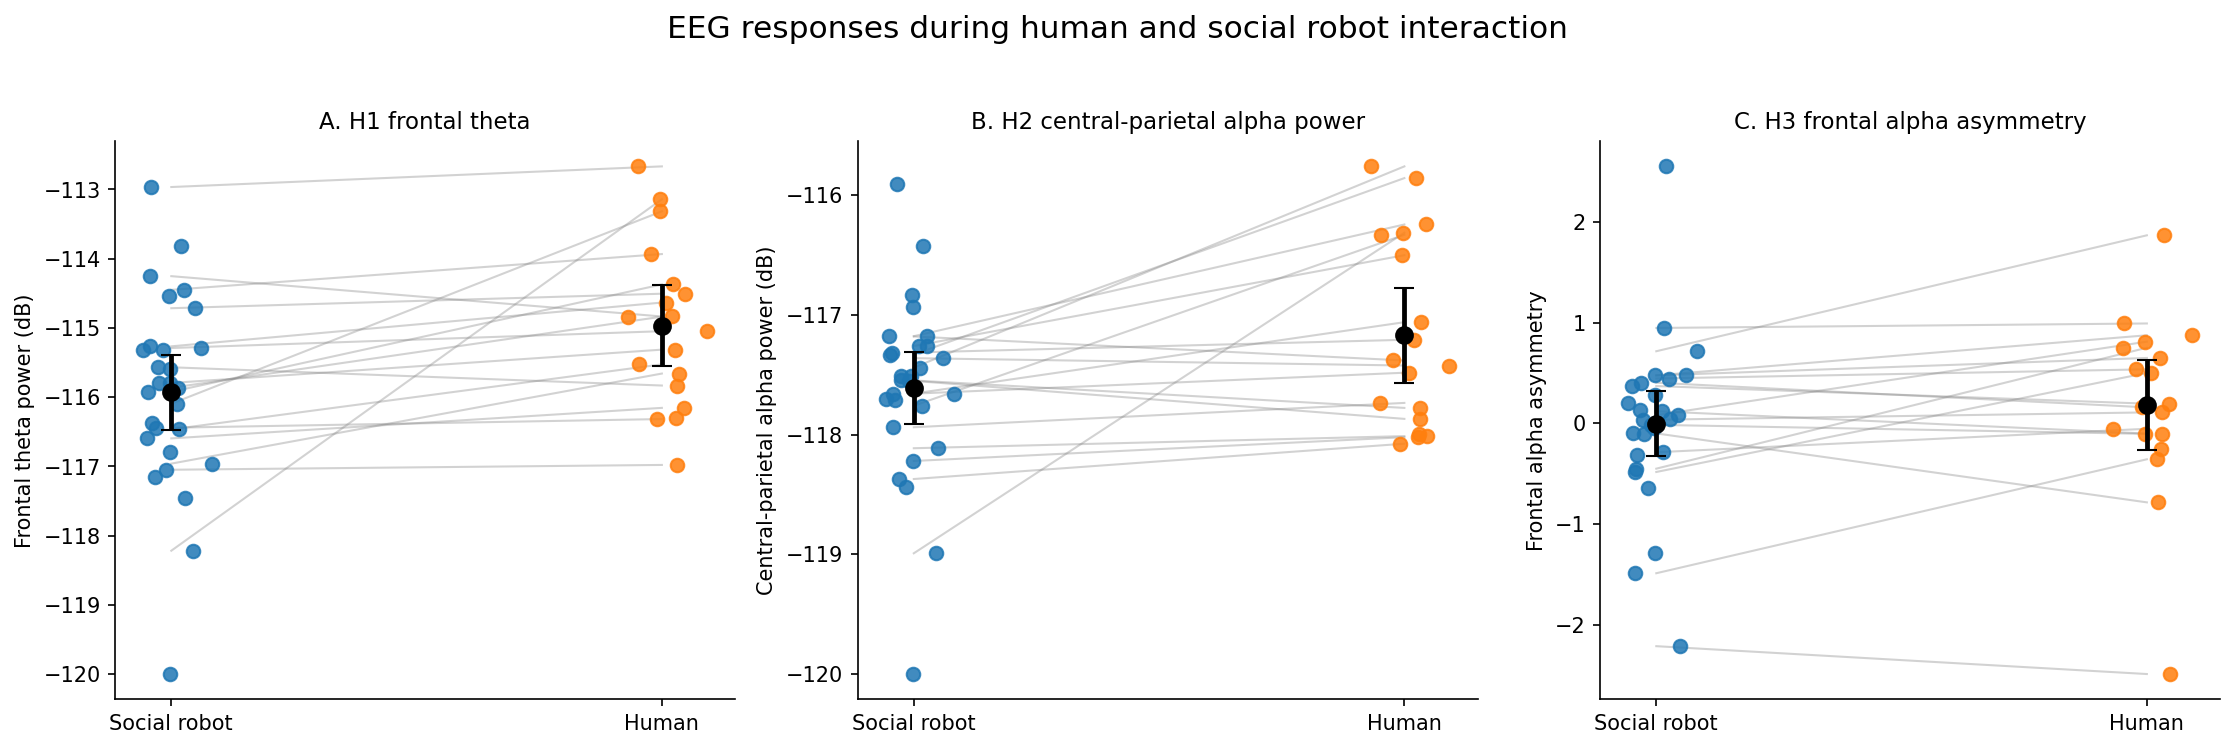

In [ ]:
# ============================================================
# BLOCK 10. H1-H3 main figure
#
# Shows all participant-condition data used by the primary models.
# Complete pairs are connected; incomplete participants remain visible.
# ============================================================

def get_condition_term_p(primary_results, model_label):
    tmp = primary_results[
        (primary_results["model"] == model_label)
        & (primary_results["term"] == "condition[T.Human]")
    ]

    if len(tmp) == 0:
        return np.nan

    return tmp["p"].iloc[0]


def mean_ci(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    m = np.nanmean(x)
    se = stats.sem(x, nan_policy="omit")
    h = se * stats.t.ppf(0.975, len(x) - 1)

    return m, m - h, m + h


def participant_condition_panel(ax, df_sc, outcome_col, ylabel, title, model_label):
    plot_df = df_sc[["subjectID", "condition", outcome_col]].dropna().copy()

    plot_df["x"] = plot_df["condition"].map({
        ROBOT_EVENT: 0,
        HUMAN_EVENT: 1
    }).astype(float)

    rng = np.random.default_rng(12345)
    plot_df["x_jitter"] = plot_df["x"] + rng.normal(0, 0.035, len(plot_df))

    wide_tmp = plot_df.pivot(
        index="subjectID",
        columns="condition",
        values=outcome_col
    )

    for sid, row in wide_tmp.dropna(subset=COND_ORDER).iterrows():
        ax.plot(
            [0, 1],
            [row[ROBOT_EVENT], row[HUMAN_EVENT]],
            color="gray",
            linewidth=1,
            alpha=0.35,
            zorder=1
        )

    for cond, xval in [(ROBOT_EVENT, 0), (HUMAN_EVENT, 1)]:
        sub = plot_df[plot_df["condition"] == cond]

        ax.scatter(
            sub["x_jitter"],
            sub[outcome_col],
            s=42,
            alpha=0.85,
            zorder=2,
            label=COND_LABELS[cond]
        )

        m, lo, hi = mean_ci(sub[outcome_col])

        ax.errorbar(
            xval,
            m,
            yerr=[[m - lo], [hi - m]],
            fmt="o",
            markersize=8,
            capsize=5,
            linewidth=2.3,
            color="black",
            zorder=3
        )

    p = get_condition_term_p(h123_primary_results, model_label)

    if np.isfinite(p):
        p_text = f"p = {p:.3f}" if p >= 0.001 else "p < .001"
    else:
        p_text = "p = NA"

    n_participants = plot_df["subjectID"].nunique()

    ax.set_title(
        f"{title}",
        fontsize=11
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels([COND_LABELS[ROBOT_EVENT], COND_LABELS[HUMAN_EVENT]])
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

participant_condition_panel(
    axes[0],
    df_sc,
    outcome_col="theta_mean",
    ylabel="Frontal theta power (dB)",
    title="A. H1 frontal theta",
    model_label="H1: frontal theta power"
)

participant_condition_panel(
    axes[1],
    df_sc,
    outcome_col="alpha_mean",
    ylabel="Central-parietal alpha power (dB)",
    title="B. H2 central-parietal alpha power",
    model_label="H2: central-parietal alpha power"
)

participant_condition_panel(
    axes[2],
    df_sc,
    outcome_col="faa_mean",
    ylabel="Frontal alpha asymmetry",
    title="C. H3 frontal alpha asymmetry",
    model_label="H3: frontal alpha asymmetry"
)

plt.suptitle(
    "EEG responses during human and social robot interaction",
    fontsize=15,
    y=1.03
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "figure_h123_primary_all_available_data.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "figure_h123_primary_all_available_data.pdf"),
    bbox_inches="tight"
)

plt.show()

# Block 11. Using 29 participants

In [ ]:
# ============================================================
# H1-H3 using all available participants
#
# Primary analysis:
# participant-condition model using df_sc
#
# This includes participants with usable EEG data in at least
# one condition. It does not require complete Human-Social robot
# pairs, so it can use the larger sample, e.g., N = 29.
#
# Sensitivity analysis:
# complete-pair paired tests using df_wide_complete
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import os

# ------------------------------------------------------------
# 1. Check required objects
# ------------------------------------------------------------

required_objects = ["df_sc", "COND_ORDER", "ROBOT_EVENT", "HUMAN_EVENT", "OUT_DIR"]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj} is not defined. Please run the earlier preprocessing blocks first.")

required_cols = [
    "subjectID",
    "condition",
    "theta_mean",
    "alpha_mean",
    "faa_mean"
]

missing_cols = [c for c in required_cols if c not in df_sc.columns]

if len(missing_cols) > 0:
    raise ValueError(f"df_sc is missing required columns: {missing_cols}")

# ------------------------------------------------------------
# 2. Clean participant-condition dataset
# ------------------------------------------------------------

df_h123_all = df_sc.copy()

df_h123_all["subjectID"] = df_h123_all["subjectID"].astype(str)

df_h123_all["condition"] = pd.Categorical(
    df_h123_all["condition"],
    categories=COND_ORDER
)

# Optional: keep only valid condition rows
df_h123_all = df_h123_all[df_h123_all["condition"].notna()].copy()

# If order exists, keep it. If not, create a missing column.
if "order" not in df_h123_all.columns:
    df_h123_all["order"] = np.nan

df_h123_all["order"] = pd.Categorical(df_h123_all["order"])

print("Participants with usable EEG in at least one condition:",
      df_h123_all["subjectID"].nunique())

print("Participant-condition rows:",
      len(df_h123_all))

print("\nCondition counts:")
display(df_h123_all["condition"].value_counts(dropna=False))

print("\nCondition availability by participant:")
df_condition_availability = (
    df_h123_all
    .assign(has_condition=1)
    .pivot_table(
        index="subjectID",
        columns="condition",
        values="has_condition",
        aggfunc="max",
        fill_value=0,
        observed=True
    )
    .reset_index()
)

for cond in COND_ORDER:
    if cond not in df_condition_availability.columns:
        df_condition_availability[cond] = 0

df_condition_availability["has_both_conditions"] = (
    (df_condition_availability[ROBOT_EVENT] == 1)
    & (df_condition_availability[HUMAN_EVENT] == 1)
)

display(df_condition_availability)

print("N with both conditions:",
      df_condition_availability["has_both_conditions"].sum())

print("N with only one condition:",
      (~df_condition_availability["has_both_conditions"]).sum())

# ------------------------------------------------------------
# 3. Model helper functions
# ------------------------------------------------------------

def tidy_model_result(model, model_name, model_type, outcome_col):
    ci = model.conf_int()
    rows = []

    for term in model.params.index:
        if "Group Var" in term or term.lower().endswith("var"):
            continue

        rows.append({
            "hypothesis": model_name,
            "outcome": outcome_col,
            "model_type": model_type,
            "term": term,
            "estimate": model.params.get(term, np.nan),
            "se": model.bse.get(term, np.nan) if hasattr(model.bse, "get") else np.nan,
            "p": model.pvalues.get(term, np.nan) if hasattr(model.pvalues, "get") else np.nan,
            "ci_low": ci.loc[term, 0] if term in ci.index else np.nan,
            "ci_high": ci.loc[term, 1] if term in ci.index else np.nan,
            "n_obs": int(model.nobs),
            "n_participants": model.model.data.frame["subjectID"].nunique()
        })

    return pd.DataFrame(rows)


def fit_h123_all_available(df, outcome_col, hypothesis_label):
    """
    Uses one row per participant-condition.

    This model uses all participants with usable EEG data in at least
    one condition. It tests whether the human condition differs from
    the social robot condition while accounting for participant clustering.

    If MixedLM fails or produces a singular fit, it falls back to OLS
    with participant-clustered standard errors.
    """

    model_df = df[["subjectID", "condition", "order", outcome_col]].dropna(subset=["subjectID", "condition", outcome_col]).copy()

    model_df["condition"] = pd.Categorical(
        model_df["condition"],
        categories=COND_ORDER
    )

    model_df["order"] = pd.Categorical(model_df["order"])

    # Include order only if there is usable variation.
    rhs = "condition"

    if "order" in model_df.columns and model_df["order"].nunique(dropna=True) > 1:
        rhs += " + order"

    formula = f"{outcome_col} ~ {rhs}"

    print("\n" + "=" * 80)
    print(hypothesis_label)
    print("Formula:", formula)
    print("N participants:", model_df["subjectID"].nunique())
    print("N participant-condition observations:", len(model_df))
    print("Condition counts:")
    print(model_df["condition"].value_counts())

    try:
        model = smf.mixedlm(
            formula,
            data=model_df,
            groups=model_df["subjectID"]
        ).fit(
            reml=False,
            method="lbfgs",
            maxiter=1000
        )

        model_type = "MixedLM with participant random intercept"

        # If variance is essentially zero, use clustered OLS as a robustness check.
        if hasattr(model, "cov_re") and np.all(np.isclose(model.cov_re.values, 0)):
            print("Warning: Random-intercept variance is near zero. Also consider clustered OLS.")

    except Exception as e:
        print("MixedLM failed. Falling back to OLS with participant-clustered SEs.")
        print("Error:", e)

        model = smf.ols(
            formula,
            data=model_df
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_df["subjectID"]}
        )

        model_type = "OLS with participant-clustered SEs"

    print(model.summary())

    tidy = tidy_model_result(
        model=model,
        model_name=hypothesis_label,
        model_type=model_type,
        outcome_col=outcome_col
    )

    return {
        "model": model,
        "tidy": tidy,
        "data": model_df,
        "formula": formula,
        "model_type": model_type
    }

# ------------------------------------------------------------
# 4. Run H1-H3 with all available participants
# ------------------------------------------------------------

h123_all_specs = {
    "H1": {
        "outcome_col": "theta_mean",
        "label": "H1: frontal theta power"
    },
    "H2": {
        "outcome_col": "alpha_mean",
        "label": "H2: central-parietal alpha power"
    },
    "H3": {
        "outcome_col": "faa_mean",
        "label": "H3: frontal alpha asymmetry"
    }
}

h123_all_models = {}
h123_all_results_list = []

for key, spec in h123_all_specs.items():
    out = fit_h123_all_available(
        df=df_h123_all,
        outcome_col=spec["outcome_col"],
        hypothesis_label=spec["label"]
    )

    h123_all_models[key] = out
    h123_all_results_list.append(out["tidy"])

h123_all_results = pd.concat(h123_all_results_list, ignore_index=True)

# Extract the condition effect only.
# Because condition categories are [AI, Human],
# condition[T.Human] = Human minus social robot.
h123_all_condition_effects = h123_all_results[
    h123_all_results["term"] == "condition[T.Human]"
].copy()

h123_all_results.to_csv(
    os.path.join(OUT_DIR, "h123_all_available_participant_condition_models_full.csv"),
    index=False
)

h123_all_condition_effects.to_csv(
    os.path.join(OUT_DIR, "h123_all_available_participant_condition_models_condition_effects.csv"),
    index=False
)

print("\nH1-H3 condition effects using all available participant-condition data:")
display(h123_all_condition_effects)

# ------------------------------------------------------------
# 5. Complete-pair paired tests as sensitivity analyses
# ------------------------------------------------------------

if "df_wide_complete" not in globals():
    print("\ndf_wide_complete is not defined, so complete-pair sensitivity tests were skipped.")

else:

    def paired_sensitivity(df_wide_complete, ai_col, human_col, label):
        ai = pd.to_numeric(df_wide_complete[ai_col], errors="coerce")
        human = pd.to_numeric(df_wide_complete[human_col], errors="coerce")

        keep = np.isfinite(ai) & np.isfinite(human)

        ai = ai[keep]
        human = human[keep]

        diff = human - ai

        t_res = stats.ttest_1samp(diff, 0, nan_policy="omit")

        dz = diff.mean() / diff.std(ddof=1)

        ci = stats.t.interval(
            confidence=0.95,
            df=len(diff) - 1,
            loc=diff.mean(),
            scale=stats.sem(diff)
        )

        return {
            "hypothesis": label,
            "n_complete_pairs": len(diff),
            "mean_social_robot": ai.mean(),
            "mean_human": human.mean(),
            "mean_diff_human_minus_social_robot": diff.mean(),
            "ci_low": ci[0],
            "ci_high": ci[1],
            "t": t_res.statistic,
            "p": t_res.pvalue,
            "cohens_dz": dz
        }

    h123_paired_sensitivity = pd.DataFrame([
        paired_sensitivity(
            df_wide_complete,
            ai_col="theta_mean_AI",
            human_col="theta_mean_Human",
            label="H1: frontal theta power"
        ),
        paired_sensitivity(
            df_wide_complete,
            ai_col="alpha_mean_AI",
            human_col="alpha_mean_Human",
            label="H2: central-parietal alpha power"
        ),
        paired_sensitivity(
            df_wide_complete,
            ai_col="faa_mean_AI",
            human_col="faa_mean_Human",
            label="H3: frontal alpha asymmetry"
        )
    ])

    h123_paired_sensitivity.to_csv(
        os.path.join(OUT_DIR, "h123_complete_pair_paired_sensitivity_tests.csv"),
        index=False
    )

    print("\nComplete-pair paired sensitivity tests:")
    display(h123_paired_sensitivity)

Participants with usable EEG in at least one condition: 29
Participant-condition rows: 46

Condition counts:


,count
condition,
AI,28
Human,18



Condition availability by participant:


condition,subjectID,AI,Human,has_both_conditions
0,25_06_25_1_1,1,1,True
1,25_06_25_2_2,1,1,True
2,25_06_25_5_5,1,0,False
3,25_07_01_1_1,1,0,False
4,25_07_01_2_2,1,1,True
5,25_07_01_4_4,1,1,True
6,25_07_01_6_6,1,1,True
7,25_07_01_8_8,1,1,True
8,25_07_02_2_2,1,0,False
9,25_07_02_3_3,1,1,True


N with both conditions: 17
N with only one condition: 12

H1: frontal theta power
Formula: theta_mean ~ condition + order
N participants: 29
N participant-condition observations: 46
Condition counts:
condition
AI       28
Human    18
Name: count, dtype: int64
MixedLM failed. Falling back to OLS with participant-clustered SEs.
Error: Singular matrix
                            OLS Regression Results                            
Dep. Variable:             theta_mean   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     5.239
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0117
Time:                        12:36:55   Log-Likelihood:                -76.960
No. Observations:                  46   AIC:                             159.9
Df Residuals:                      43   BIC:                             165.4
Df Model:        

,hypothesis,outcome,model_type,term,estimate,se,p,ci_low,ci_high,n_obs,n_participants
1,H1: frontal theta power,theta_mean,OLS with participant-clustered SEs,condition[T.Human],0.971465,0.337916,0.004042,0.309162,1.633767,46,29
4,H2: central-parietal alpha power,alpha_mean,OLS with participant-clustered SEs,condition[T.Human],0.445621,0.225291,0.047931,0.004059,0.887183,46,29
7,H3: frontal alpha asymmetry,faa_mean,MixedLM with participant random intercept,condition[T.Human],0.243050,0.132535,0.066676,-0.016714,0.502814,46,29



Complete-pair paired sensitivity tests:


,hypothesis,n_complete_pairs,mean_social_robot,mean_human,mean_diff_human_minus_social_robot,ci_low,ci_high,t,p,cohens_dz
0,H1: frontal theta power,17,-115.758814,-114.885666,0.873148,0.189688,1.556609,2.708264,0.015507,0.656851
1,H2: central-parietal alpha power,17,-117.698950,-117.121662,0.577288,0.156015,0.998561,2.904994,0.010333,0.704565
2,H3: frontal alpha asymmetry,17,-0.057281,0.208654,0.265935,-0.030202,0.562073,1.903701,0.075095,0.461715


# Block 12. H4

Survey merge status:


,n,count
0,both,45
1,left_only,0
2,right_only,0



Participants with H4 survey scores:
45


,subjectID,enjoyment_ai,enjoyment_human,Enjoyment_diff,cooperative_ai,cooperative_human,Cooperativeness_diff
0,25_06_25_1_1,6.000000,6.000000,0.000000,6.0,6.0,0.0
1,25_06_25_2_2,4.666667,7.000000,2.333333,6.0,7.0,1.0
2,25_06_25_4_4,3.666667,6.333333,2.666667,3.0,7.0,4.0
3,25_06_25_5_5,4.333333,5.666667,1.333333,5.0,3.0,-2.0
4,25_07_01_1_1,2.333333,7.000000,4.666667,4.0,7.0,3.0



H4 all-available participant-condition dataset:
Participants: 29
Participant-condition rows: 46


...

,model,model_type,term,estimate,se,p,ci_low,ci_high,n_obs,n_subjects,p_fdr_bh,significant_fdr_q05
0,Enjoyment ~ theta_mean × condition,OLS with participant-clustered SEs,Intercept,4.450362,0.288400,1.009899e-53,3.885108,5.015617,46,29,NaN,NaN
1,Enjoyment ~ theta_mean × condition,OLS with participant-clustered SEs,condition[T.Human],1.426224,0.303906,2.692563e-06,0.830579,2.021868,46,29,NaN,NaN
2,Enjoyment ~ theta_mean × condition,OLS with participant-clustered SEs,order[T.2.0],-0.798459,0.301235,8.034526e-03,-1.388870,-0.208049,46,29,NaN,NaN
3,Enjoyment ~ theta_mean × condition,OLS with participant-clustered SEs,theta_mean_z,-0.013583,0.143055,9.243570e-01,-0.293965,0.266800,46,29,NaN,NaN
4,Enjoyment ~ theta_mean × condition,OLS with participant-clustered SEs,theta_mean_z:condition[T.Human],0.225446,0.217658,3.003044e-01,-0.201156,0.652047,46,29,0.450457,False
5,Enjoyment ~ alpha_mean × condition,OLS with participant-clustered SEs,Intercept,4.389683,0.285119,1.741639e-53,3.830861,4.948506,46,29,NaN,NaN
6,Enjoyment ~ alpha_mean × condition,OLS with participant-clustered SEs,condition[T.Human],1.532213,0.293722,1.822974e-07,0.956528,2.107898,46,29,NaN,NaN
7,Enjoyment ~ alpha_mean × condition,OLS with participant-clustered SEs,order[T.2.0],-0.737201,0.306017,1.599559e-02,-1.336984,-0.137418,46,29,NaN,NaN
8,Enjoyment ~ alpha_mean × condition,OLS with participant-clustered SEs,alpha_mean_z,-0.166652,0.143145,2.443365e-01,-0.447212,0.113908,46,29,NaN,NaN
9,Enjoyment ~ alpha_mean × condition,OLS with participant-clustered SEs,alpha_mean_z:condition[T.Human],0.216933,0.182126,2.336083e-01,-0.140027,0.573893,46,29,0.450457,False



H4 complete-pair difference-score dataset:
Participants: 17


,subjectID,theta_mean_AI,theta_mean_Human,alpha_mean_AI,alpha_mean_Human,faa_mean_AI,faa_mean_Human,n_epochs_AI,n_epochs_Human,Theta_diff,AlphaPower_diff,FAA_diff,enjoyment_ai,enjoyment_human,Enjoyment_diff,cooperative_ai,cooperative_human,Cooperativeness_diff
0,25_06_25_1_1,-116.594764,-116.153831,-117.178662,-116.246116,0.369983,0.195009,250.0,139.0,0.440933,0.932546,-0.174973,6.000000,6.000000,0.000000,6.0,6.0,0.0
1,25_06_25_2_2,-116.440857,-116.315276,-118.371119,-118.076296,0.403171,0.158293,90.0,19.0,0.125580,0.294823,-0.244878,4.666667,7.000000,2.333333,6.0,7.0,1.0
2,25_07_01_2_2,-115.921986,-114.371352,-117.331707,-115.858843,-0.100601,-0.785964,466.0,127.0,1.550634,1.472863,-0.685363,3.666667,6.333333,2.666667,5.0,5.0,0.0
3,25_07_01_4_4,-115.864209,-114.836453,-117.441010,-115.761059,-0.287993,-0.054457,12.0,28.0,1.027756,1.679951,0.233536,4.666667,5.333333,0.666667,4.0,7.0,3.0
4,25_07_01_6_6,-116.959027,-115.658173,-117.657661,-117.061789,0.716108,1.868405,201.0,160.0,1.300854,0.595872,1.152297,4.333333,4.333333,0.000000,4.0,5.0,1.0



H4 complete-pair difference-score model
Model: Enjoyment_diff ~ Theta_diff
Formula: Enjoyment_diff ~ Theta_diff_z
N: 17
                            OLS Regression Results                            
Dep. Variable:         Enjoyment_diff   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.042
Method:                 Least Squares   F-statistic:                    0.7002
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.416
Time:                        12:36:57   Log-Likelihood:                -25.814
No. Observations:                  17   AIC:                             55.63
Df Residuals:                      15   BIC:                             57.29
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------

,model,formula,predictor,b,se_HC3,t,p,ci_low,ci_high,n,r_squared,p_fdr_bh,significant_fdr_q05
0,Enjoyment_diff ~ Theta_diff,Enjoyment_diff ~ Theta_diff_z,Theta_diff_z,0.174153,0.208121,0.836789,0.402711,-0.233756,0.582062,17,0.022859,0.604066,False
1,Enjoyment_diff ~ AlphaPower_diff,Enjoyment_diff ~ AlphaPower_diff_z,AlphaPower_diff_z,0.010937,0.289320,0.037803,0.969844,-0.556120,0.577995,17,0.000090,0.969844,False
2,Enjoyment_diff ~ FAA_diff,Enjoyment_diff ~ FAA_diff_z,FAA_diff_z,-0.480572,0.211715,-2.269902,0.023214,-0.895525,-0.065618,17,0.174065,0.069641,False


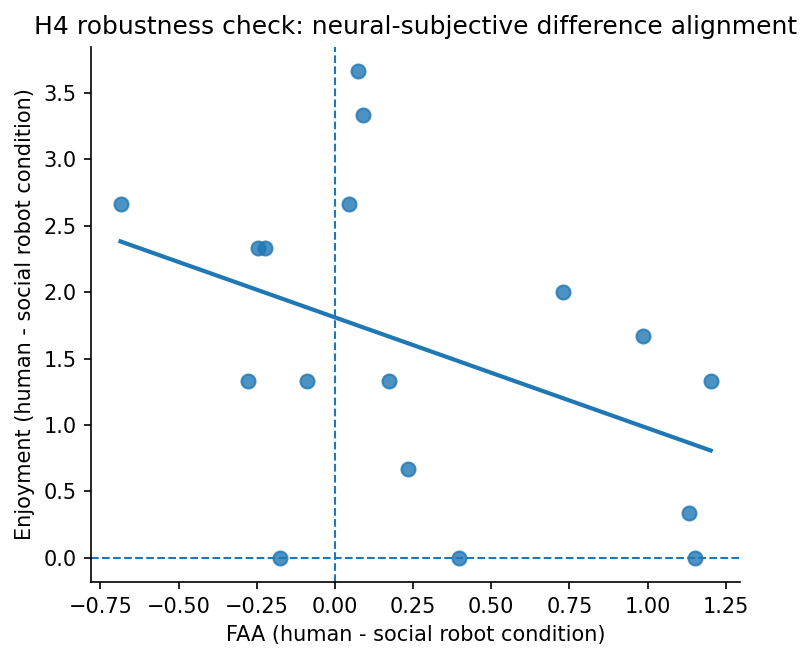

In [ ]:
# ============================================================
# H4: Neural-subjective alignment
#
# Two complementary analyses:
#
# Analysis 1. All-available participant-condition model
#   Uses participants with usable EEG in at least one condition.
#   Model:
#       Enjoyment ~ neural_z * condition + order + (1 | subject)
#
# Analysis 2. Complete-pair difference-score robustness model
#   Uses participants with usable EEG in both conditions.
#   Model:
#       Enjoyment_diff ~ Neural_diff_z
#
# This code assumes the following already exist:
#   df_sc
#   df_summary
#   df_survey OR SURVEY_XLSX
#   ANALYSIS_DIR
#   OUT_DIR
#   COND_ORDER
#   ROBOT_EVENT
#   HUMAN_EVENT
# ============================================================

import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------

SURVEY_XLSX = os.path.join(ANALYSIS_DIR, "Pepper_experiment_surveydata.xlsx")

# Use only interaction enjoyment for the current manuscript.
# Enjoyment = mean of unpleasant-pleasant, not enjoyable-enjoyable, unsatisfying-satisfying.
H4_OUTCOMES_PC = {
    "Enjoyment": {
        "ai_col": "enjoyment_ai",
        "human_col": "enjoyment_human",
        "diff_col": "Enjoyment_diff"
    }
}

# Optional, only if you later decide to include cooperativeness:
# H4_OUTCOMES_PC["Cooperativeness"] = {
#     "ai_col": "cooperative_ai",
#     "human_col": "cooperative_human",
#     "diff_col": "Cooperativeness_diff"
# }

H4_NEURAL_PC = {
    "theta_mean": {
        "label": "Frontal theta power",
        "diff_col": "Theta_diff"
    },
    "alpha_mean": {
        "label": "Central-parietal alpha power",
        "diff_col": "AlphaPower_diff"
    },
    "faa_mean": {
        "label": "Frontal alpha asymmetry",
        "diff_col": "FAA_diff"
    }
}

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def clean_participant_id(x):
    """
    Convert EEG subject IDs and survey IDs into comparable digit-only strings.

    Example:
    25_06_25_1_1 -> 25062511
    25062511.0    -> 25062511
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x.endswith(".0"):
        x = x[:-2]

    x = "".join([ch for ch in x if ch.isdigit()])

    return x if len(x) > 0 else np.nan


def zscore_series(x):
    x = pd.to_numeric(x, errors="coerce")
    sd = x.std(ddof=1)

    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=x.index)

    return (x - x.mean()) / sd


def tidy_model_result(model, model_name, model_type, n_subjects):
    ci = model.conf_int()
    rows = []

    for term in model.params.index:
        if "Group Var" in term or term.lower().endswith("var"):
            continue

        rows.append({
            "model": model_name,
            "model_type": model_type,
            "term": term,
            "estimate": model.params.get(term, np.nan),
            "se": model.bse.get(term, np.nan) if hasattr(model.bse, "get") else np.nan,
            "p": model.pvalues.get(term, np.nan) if hasattr(model.pvalues, "get") else np.nan,
            "ci_low": ci.loc[term, 0] if term in ci.index else np.nan,
            "ci_high": ci.loc[term, 1] if term in ci.index else np.nan,
            "n_obs": int(model.nobs),
            "n_subjects": int(n_subjects)
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 2. Load and prepare survey data
# ------------------------------------------------------------

df_survey_h4 = pd.read_excel(SURVEY_XLSX, sheet_name=0).copy()

required_survey_cols = [
    "ID",
    "Q1_1", "Q1_2", "Q1_4",
    "Q3_1", "Q3_2", "Q3_4"
]

missing_cols = [c for c in required_survey_cols if c not in df_survey_h4.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required survey columns: {missing_cols}")

df_survey_h4["ID_clean"] = df_survey_h4["ID"].apply(clean_participant_id)

# Drop duplicate survey IDs if needed.
df_survey_h4 = (
    df_survey_h4
    .drop_duplicates(subset=["ID_clean"], keep="last")
    .copy()
)

# Convert enjoyment items to numeric.
enjoyment_q1_items = ["Q1_1", "Q1_2", "Q1_4"]
enjoyment_q3_items = ["Q3_1", "Q3_2", "Q3_4"]

for col in enjoyment_q1_items + enjoyment_q3_items:
    df_survey_h4[col] = pd.to_numeric(df_survey_h4[col], errors="coerce")

df_survey_h4["enjoyment_Q1"] = df_survey_h4[enjoyment_q1_items].mean(axis=1)
df_survey_h4["enjoyment_Q3"] = df_survey_h4[enjoyment_q3_items].mean(axis=1)

# Optional: if you need cooperativeness later.
if "Q1_9" in df_survey_h4.columns and "Q3_9" in df_survey_h4.columns:
    df_survey_h4["cooperative_Q1"] = pd.to_numeric(df_survey_h4["Q1_9"], errors="coerce")
    df_survey_h4["cooperative_Q3"] = pd.to_numeric(df_survey_h4["Q3_9"], errors="coerce")

# ------------------------------------------------------------
# 3. Create condition-specific survey scores using condition order
# ------------------------------------------------------------

df_order = df_summary[["subjectID", "Label"]].copy()
df_order["subjectID"] = df_order["subjectID"].astype(str)
df_order["ID_clean"] = df_order["subjectID"].apply(clean_participant_id)

df_h4_survey = df_order.merge(
    df_survey_h4,
    on="ID_clean",
    how="left",
    indicator=True
)

print("Survey merge status:")
display(
    df_h4_survey["_merge"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "merge_status", "_merge": "n"})
)

# Q1 and Q3 correspond to the first and second conversation.
# If Label begins with AI, Q1 = AI and Q3 = Human.
# If Label begins with Human, Q1 = Human and Q3 = AI.

df_h4_survey["enjoyment_ai"] = np.where(
    df_h4_survey["Label"].astype(str).str.split("-").str[0] == ROBOT_EVENT,
    df_h4_survey["enjoyment_Q1"],
    df_h4_survey["enjoyment_Q3"]
)

df_h4_survey["enjoyment_human"] = np.where(
    df_h4_survey["Label"].astype(str).str.split("-").str[0] == ROBOT_EVENT,
    df_h4_survey["enjoyment_Q3"],
    df_h4_survey["enjoyment_Q1"]
)

df_h4_survey["Enjoyment_diff"] = (
    df_h4_survey["enjoyment_human"] - df_h4_survey["enjoyment_ai"]
)

# Optional cooperativeness construction if available.
if "cooperative_Q1" in df_h4_survey.columns and "cooperative_Q3" in df_h4_survey.columns:
    df_h4_survey["cooperative_ai"] = np.where(
        df_h4_survey["Label"].astype(str).str.split("-").str[0] == ROBOT_EVENT,
        df_h4_survey["cooperative_Q1"],
        df_h4_survey["cooperative_Q3"]
    )

    df_h4_survey["cooperative_human"] = np.where(
        df_h4_survey["Label"].astype(str).str.split("-").str[0] == ROBOT_EVENT,
        df_h4_survey["cooperative_Q3"],
        df_h4_survey["cooperative_Q1"]
    )

    df_h4_survey["Cooperativeness_diff"] = (
        df_h4_survey["cooperative_human"] - df_h4_survey["cooperative_ai"]
    )

df_h4_subj = df_h4_survey[
    [
        "subjectID",
        "enjoyment_ai",
        "enjoyment_human",
        "Enjoyment_diff"
    ]
    + (
        ["cooperative_ai", "cooperative_human", "Cooperativeness_diff"]
        if "Cooperativeness_diff" in df_h4_survey.columns
        else []
    )
].copy()

print("\nParticipants with H4 survey scores:")
print(df_h4_subj["subjectID"].nunique())
display(df_h4_subj.head())

df_h4_subj.to_csv(
    os.path.join(OUT_DIR, "h4_condition_specific_survey_scores.csv"),
    index=False
)

# ------------------------------------------------------------
# 4. Analysis 1: all-available participant-condition H4 models
# ------------------------------------------------------------

df_h4_pc = df_sc.merge(
    df_h4_subj,
    on="subjectID",
    how="inner"
).copy()

df_h4_pc["condition"] = pd.Categorical(
    df_h4_pc["condition"],
    categories=COND_ORDER
)

# Construct condition-specific outcome in long format.
df_h4_pc["Enjoyment"] = np.where(
    df_h4_pc["condition"].astype(str) == HUMAN_EVENT,
    df_h4_pc["enjoyment_human"],
    df_h4_pc["enjoyment_ai"]
)

if "cooperative_ai" in df_h4_pc.columns and "cooperative_human" in df_h4_pc.columns:
    df_h4_pc["Cooperativeness"] = np.where(
        df_h4_pc["condition"].astype(str) == HUMAN_EVENT,
        df_h4_pc["cooperative_human"],
        df_h4_pc["cooperative_ai"]
    )

print("\nH4 all-available participant-condition dataset:")
print("Participants:", df_h4_pc["subjectID"].nunique())
print("Participant-condition rows:", len(df_h4_pc))
display(df_h4_pc["condition"].value_counts(dropna=False))

def fit_h4_participant_condition_model(df, outcome_col, neural_col):
    """
    All-available H4 model.

    Tests whether condition-specific neural activity predicts
    condition-specific enjoyment and whether this association differs
    between social robot and human conditions.

    Model:
        outcome ~ neural_z * condition + order + (1 | subject)
    """

    keep_cols = ["subjectID", "condition", outcome_col, neural_col]

    if "order" in df.columns:
        keep_cols.append("order")

    model_df = df[keep_cols].dropna().copy()

    model_df["subjectID"] = model_df["subjectID"].astype(str)

    model_df["condition"] = pd.Categorical(
        model_df["condition"],
        categories=COND_ORDER
    )

    model_df[f"{neural_col}_z"] = zscore_series(model_df[neural_col])

    if "order" in model_df.columns:
        model_df["order"] = pd.Categorical(model_df["order"])
    else:
        model_df["order"] = np.nan

    rhs = f"{neural_col}_z * condition"

    if model_df["order"].nunique(dropna=True) > 1:
        rhs += " + order"

    formula = f"{outcome_col} ~ {rhs}"
    model_name = f"{outcome_col} ~ {neural_col} × condition"

    print("\n" + "=" * 80)
    print("H4 all-available participant-condition model")
    print("Model:", model_name)
    print("Formula:", formula)
    print("Participants:", model_df["subjectID"].nunique())
    print("Rows:", len(model_df))

    try:
        model = smf.mixedlm(
            formula,
            data=model_df,
            groups=model_df["subjectID"]
        ).fit(
            reml=False,
            method="lbfgs",
            maxiter=1000
        )

        model_type = "MixedLM with participant random intercept"

    except Exception as e:
        print("MixedLM failed. Falling back to OLS with participant-clustered SEs.")
        print("Error:", e)

        model = smf.ols(
            formula,
            data=model_df
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": model_df["subjectID"]}
        )

        model_type = "OLS with participant-clustered SEs"

    print(model.summary())

    tidy = tidy_model_result(
        model=model,
        model_name=model_name,
        model_type=model_type,
        n_subjects=model_df["subjectID"].nunique()
    )

    return {
        "model": model,
        "tidy": tidy,
        "data": model_df,
        "formula": formula,
        "model_type": model_type
    }

h4_pc_models = {}
h4_pc_results_list = []

for outcome_col in H4_OUTCOMES_PC.keys():
    if outcome_col not in df_h4_pc.columns:
        continue

    for neural_col in H4_NEURAL_PC.keys():
        key = f"{outcome_col}__{neural_col}"

        out = fit_h4_participant_condition_model(
            df=df_h4_pc,
            outcome_col=outcome_col,
            neural_col=neural_col
        )

        h4_pc_models[key] = out
        h4_pc_results_list.append(out["tidy"])

h4_pc_results = pd.concat(h4_pc_results_list, ignore_index=True)

# Correct the interaction tests across the planned H4 all-available models.
# The interaction term asks whether the neural-outcome association differs by condition.
h4_pc_interaction = h4_pc_results[
    h4_pc_results["term"].str.contains(":condition", regex=False, na=False)
].copy()

if len(h4_pc_interaction) > 0:
    reject, p_adj, _, _ = multipletests(
        h4_pc_interaction["p"],
        alpha=0.05,
        method="fdr_bh"
    )

    h4_pc_interaction["p_fdr_bh"] = p_adj
    h4_pc_interaction["significant_fdr_q05"] = reject

    h4_pc_results = h4_pc_results.merge(
        h4_pc_interaction[["model", "term", "p_fdr_bh", "significant_fdr_q05"]],
        on=["model", "term"],
        how="left"
    )

h4_pc_results.to_csv(
    os.path.join(OUT_DIR, "h4_all_available_participant_condition_models.csv"),
    index=False
)

print("\nH4 all-available participant-condition results:")
display(h4_pc_results)

# ------------------------------------------------------------
# 5. Analysis 2: complete-pair difference-score robustness models
# ------------------------------------------------------------

# Convert df_sc to wide format for complete-pair difference scores.
df_eeg_wide = df_sc.pivot(
    index="subjectID",
    columns="condition",
    values=["theta_mean", "alpha_mean", "faa_mean", "n_epochs"]
)

df_eeg_wide.columns = [
    f"{var}_{condition}"
    for var, condition in df_eeg_wide.columns
]

df_eeg_wide = df_eeg_wide.reset_index()

required_cols = [
    "theta_mean_AI", "theta_mean_Human",
    "alpha_mean_AI", "alpha_mean_Human",
    "faa_mean_AI", "faa_mean_Human"
]

for col in required_cols:
    if col not in df_eeg_wide.columns:
        df_eeg_wide[col] = np.nan

df_eeg_wide = df_eeg_wide.dropna(subset=required_cols).copy()

df_eeg_wide["Theta_diff"] = (
    df_eeg_wide["theta_mean_Human"] - df_eeg_wide["theta_mean_AI"]
)

df_eeg_wide["AlphaPower_diff"] = (
    df_eeg_wide["alpha_mean_Human"] - df_eeg_wide["alpha_mean_AI"]
)

df_eeg_wide["FAA_diff"] = (
    df_eeg_wide["faa_mean_Human"] - df_eeg_wide["faa_mean_AI"]
)

df_h4_diff = df_eeg_wide.merge(
    df_h4_subj,
    on="subjectID",
    how="inner"
)

print("\nH4 complete-pair difference-score dataset:")
print("Participants:", df_h4_diff["subjectID"].nunique())
display(df_h4_diff.head())

def fit_h4_difference_model(df, outcome_diff_col, neural_diff_col):
    """
    Complete-pair H4 robustness model.

    Tests whether within-person Human minus social robot neural difference
    predicts within-person Human minus social robot enjoyment difference.

    Model:
        outcome_diff ~ neural_diff_z

    Uses HC3 robust standard errors because N is small.
    """

    model_df = df[[outcome_diff_col, neural_diff_col]].dropna().copy()

    model_df[f"{neural_diff_col}_z"] = zscore_series(model_df[neural_diff_col])

    formula = f"{outcome_diff_col} ~ {neural_diff_col}_z"

    model = smf.ols(
        formula,
        data=model_df
    ).fit(cov_type="HC3")

    model_name = f"{outcome_diff_col} ~ {neural_diff_col}"

    print("\n" + "=" * 80)
    print("H4 complete-pair difference-score model")
    print("Model:", model_name)
    print("Formula:", formula)
    print("N:", int(model.nobs))
    print(model.summary())

    ci = model.conf_int()
    predictor = f"{neural_diff_col}_z"

    result = {
        "model": model_name,
        "formula": formula,
        "predictor": predictor,
        "b": model.params[predictor],
        "se_HC3": model.bse[predictor],
        "t": model.tvalues[predictor],
        "p": model.pvalues[predictor],
        "ci_low": ci.loc[predictor, 0],
        "ci_high": ci.loc[predictor, 1],
        "n": int(model.nobs),
        "r_squared": model.rsquared
    }

    return {
        "model": model,
        "result": result,
        "data": model_df,
        "formula": formula
    }

h4_diff_models = {}
h4_diff_rows = []

for outcome_name, outcome_spec in H4_OUTCOMES_PC.items():
    outcome_diff_col = outcome_spec["diff_col"]

    if outcome_diff_col not in df_h4_diff.columns:
        continue

    for neural_col, neural_spec in H4_NEURAL_PC.items():
        neural_diff_col = neural_spec["diff_col"]

        key = f"{outcome_diff_col}__{neural_diff_col}"

        out = fit_h4_difference_model(
            df=df_h4_diff,
            outcome_diff_col=outcome_diff_col,
            neural_diff_col=neural_diff_col
        )

        h4_diff_models[key] = out
        h4_diff_rows.append(out["result"])

h4_diff_results = pd.DataFrame(h4_diff_rows)

# FDR correction across planned complete-pair H4 tests.
if len(h4_diff_results) > 0:
    reject, p_adj, _, _ = multipletests(
        h4_diff_results["p"],
        alpha=0.05,
        method="fdr_bh"
    )

    h4_diff_results["p_fdr_bh"] = p_adj
    h4_diff_results["significant_fdr_q05"] = reject

h4_diff_results.to_csv(
    os.path.join(OUT_DIR, "h4_complete_pair_difference_score_models.csv"),
    index=False
)

print("\nH4 complete-pair difference-score results:")
display(h4_diff_results)

# ------------------------------------------------------------
# 6. Optional H4 figure for the complete-pair model
# ------------------------------------------------------------

import matplotlib.pyplot as plt

def plot_h4_difference(df, neural_diff_col, outcome_diff_col, xlabel, ylabel, title):
    plot_df = df[[neural_diff_col, outcome_diff_col]].dropna().copy()

    model = smf.ols(
        f"{outcome_diff_col} ~ {neural_diff_col}",
        data=plot_df
    ).fit(cov_type="HC3")

    x = pd.to_numeric(plot_df[neural_diff_col], errors="coerce")
    y = pd.to_numeric(plot_df[outcome_diff_col], errors="coerce")

    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = model.params["Intercept"] + model.params[neural_diff_col] * x_grid

    fig, ax = plt.subplots(figsize=(5.2, 4.5))

    ax.scatter(x, y, s=45, alpha=.80)
    ax.plot(x_grid, y_grid, linewidth=2)

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    return fig, model

# Example figure: FAA difference predicting enjoyment difference.
if "FAA_diff" in df_h4_diff.columns and "Enjoyment_diff" in df_h4_diff.columns:
    fig_h4, model_h4_plot = plot_h4_difference(
        df_h4_diff,
        neural_diff_col="FAA_diff",
        outcome_diff_col="Enjoyment_diff",
        xlabel="FAA (human - social robot condition)",
        ylabel="Enjoyment (human - social robot condition)",
        title="H4 robustness check: neural-subjective difference alignment"
    )

    plt.savefig(
        os.path.join(OUT_DIR, "figure_h4_faa_enjoyment_difference.png"),
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        os.path.join(OUT_DIR, "figure_h4_faa_enjoyment_difference.pdf"),
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
print("Enjoyment statistics (mean and standard deviation) for AI and Human:")
print(f"Enjoyment AI: Mean = {df_h4_subj['enjoyment_ai'].mean():.2f}, Std = {df_h4_subj['enjoyment_ai'].std():.2f}")
print(f"Enjoyment Human: Mean = {df_h4_subj['enjoyment_human'].mean():.2f}, Std = {df_h4_subj['enjoyment_human'].std():.2f}")

Enjoyment statistics (mean and standard deviation) for AI and Human:
Enjoyment AI: Mean = 4.01, Std = 1.23
Enjoyment Human: Mean = 5.39, Std = 1.06


# Participant Descriptives

In [ ]:
# ============================================================
# Participant descriptives for BOTH EEG analysis samples
#
# Samples:
#   1. participant_condition_primary
#      = participants in df_sc, usable EEG in at least one condition
#
#   2. complete_pair_h123
#      = participants in df_wide_complete, usable EEG in both conditions
#
# Survey file:
#   Pepper_experiment_surveydata.xlsx
#
# Matching:
#   EEG subjectID <-> survey ID
#
# Variables:
#   Q10   = birth year
#   Age   = 2025 - Q10
#   Q8_3  = robot trust
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------

DATA_COLLECTION_YEAR = 2025

SURVEY_XLSX = os.path.join(
    ANALYSIS_DIR,
    "Pepper_experiment_surveydata.xlsx"
)

# ------------------------------------------------------------
# 1. Load survey data from Sheet 1
# ------------------------------------------------------------

df_survey_demo = pd.read_excel(
    SURVEY_XLSX,
    sheet_name=0
).copy()

print("Survey data shape:", df_survey_demo.shape)
print("Survey columns:")
print(df_survey_demo.columns.tolist())

# ------------------------------------------------------------
# 2. Confirm required columns exist
# ------------------------------------------------------------

required_cols = ["ID", "Q10", "Q8_3"]

missing_cols = [
    col for col in required_cols
    if col not in df_survey_demo.columns
]

if len(missing_cols) > 0:
    raise ValueError(
        f"The following required columns are missing from the survey file: {missing_cols}"
    )

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def clean_participant_id(x):
    """
    Convert EEG subject IDs and survey IDs into comparable digit-only strings.

    Examples:
        25_06_25_1_1 -> 25062511
        25062511.0    -> 25062511
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x.endswith(".0"):
        x = x[:-2]

    x = "".join([ch for ch in x if ch.isdigit()])

    return x if len(x) > 0 else np.nan


def infer_birth_year(x):
    """
    Convert Q10 to birth year.

    Handles:
        2001   -> 2001
        2001.0 -> 2001
        1      -> 2001
        01     -> 2001
        99     -> 1999

    If Q10 is not interpretable as a birth year, returns NaN.
    """
    if pd.isna(x):
        return np.nan

    try:
        val = int(float(x))
    except Exception:
        return np.nan

    # Full birth year
    if 1900 <= val <= DATA_COLLECTION_YEAR:
        return val

    # Two-digit birth year
    if 0 <= val <= 25:
        return 2000 + val

    if 26 <= val <= 99:
        return 1900 + val

    return np.nan


def summarize_variable(df, var_col, label):
    values = pd.to_numeric(df[var_col], errors="coerce").dropna()

    return {
        "variable": label,
        "column": var_col,
        "n": int(values.shape[0]),
        "mean": values.mean(),
        "sd": values.std(ddof=1),
        "min": values.min() if len(values) > 0 else np.nan,
        "max": values.max() if len(values) > 0 else np.nan
    }


def make_sample_subjects(df, sample_type):
    out = (
        df["subjectID"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .to_frame(name="subjectID")
    )

    out["sample_type"] = sample_type
    out["ID_clean"] = out["subjectID"].apply(clean_participant_id)

    return out

# ------------------------------------------------------------
# 4. Clean survey ID and create variables
# ------------------------------------------------------------

df_survey_demo["ID_clean"] = df_survey_demo["ID"].apply(clean_participant_id)

# Drop duplicate survey IDs, if any
n_before = len(df_survey_demo)

df_survey_demo = (
    df_survey_demo
    .sort_index()
    .drop_duplicates(subset=["ID_clean"], keep="last")
    .copy()
)

n_after = len(df_survey_demo)

if n_before != n_after:
    print(f"Dropped {n_before - n_after} duplicate survey ID rows.")

# Q10 = birth year
df_survey_demo["birth_year"] = df_survey_demo["Q10"].apply(infer_birth_year)

# Age = 2025 - birth year
df_survey_demo["age_2025"] = (
    DATA_COLLECTION_YEAR - df_survey_demo["birth_year"]
)

# Q8_3 = robot trust
df_survey_demo["robot_trust"] = pd.to_numeric(
    df_survey_demo["Q8_3"],
    errors="coerce"
)

# Age sanity check
age_problem_rows = df_survey_demo[
    (df_survey_demo["age_2025"].notna())
    & (
        (df_survey_demo["age_2025"] < 15)
        | (df_survey_demo["age_2025"] > 60)
    )
]

if len(age_problem_rows) > 0:
    print("\nWarning: Some computed ages look unusual. Please inspect these rows:")
    display(age_problem_rows[["ID", "Q10", "birth_year", "age_2025"]])

# ------------------------------------------------------------
# 5. Build the two analysis samples
# ------------------------------------------------------------

if "df_sc" not in globals():
    raise NameError(
        "df_sc is not defined. Run the participant-condition EEG mean block first."
    )

if "subjectID" not in df_sc.columns:
    raise ValueError("df_sc does not contain a subjectID column.")

subjects_29 = make_sample_subjects(
    df_sc,
    sample_type="participant_condition_primary"
)

# If df_wide_complete does not exist, create it from df_sc
if "df_wide_complete" not in globals():

    print(
        "df_wide_complete was not found. Creating complete-pair sample from df_sc."
    )

    df_wide_tmp = df_sc.pivot(
        index="subjectID",
        columns="condition",
        values=["theta_mean", "alpha_mean", "faa_mean"]
    )

    df_wide_tmp.columns = [
        f"{metric}_{condition}"
        for metric, condition in df_wide_tmp.columns
    ]

    df_wide_tmp = df_wide_tmp.reset_index()

    required_pair_cols = [
        "theta_mean_AI", "theta_mean_Human",
        "alpha_mean_AI", "alpha_mean_Human",
        "faa_mean_AI", "faa_mean_Human"
    ]

    for col in required_pair_cols:
        if col not in df_wide_tmp.columns:
            df_wide_tmp[col] = np.nan

    df_wide_complete = df_wide_tmp.dropna(
        subset=required_pair_cols
    ).copy()

subjects_17 = make_sample_subjects(
    df_wide_complete,
    sample_type="complete_pair_h123"
)

# Combine both samples
all_sample_subjects = pd.concat(
    [subjects_29, subjects_17],
    ignore_index=True
).drop_duplicates(subset=["subjectID", "sample_type"])

print("\nEEG sample counts before survey merge:")
display(
    all_sample_subjects
    .groupby("sample_type", as_index=False)["subjectID"]
    .nunique()
    .rename(columns={"subjectID": "n_subjects"})
)

# ------------------------------------------------------------
# 6. Merge both samples with survey data
# ------------------------------------------------------------

df_all_demo = all_sample_subjects.merge(
    df_survey_demo,
    on="ID_clean",
    how="left",
    indicator=True
)

print("\nSurvey merge status by sample:")
display(
    df_all_demo
    .groupby(["sample_type", "_merge"], observed=True)
    .size()
    .reset_index(name="n")
)

missing_survey = df_all_demo[df_all_demo["_merge"] != "both"][
    ["sample_type", "subjectID", "ID_clean"]
]

if len(missing_survey) > 0:
    print("\nParticipants in analysis samples but not found in survey file:")
    display(missing_survey)
else:
    print("\nAll participants in both analysis samples were matched to the survey file.")

# ------------------------------------------------------------
# 7. Compute descriptives for both samples
# ------------------------------------------------------------

summary_rows = []

for sample_type, subdf in df_all_demo.groupby("sample_type", observed=True):

    age_summary = summarize_variable(
        subdf,
        "age_2025",
        "Age"
    )

    trust_summary = summarize_variable(
        subdf,
        "robot_trust",
        "Robot trust"
    )

    summary_rows.append({
        "sample_type": sample_type,
        **age_summary
    })

    summary_rows.append({
        "sample_type": sample_type,
        **trust_summary
    })

descriptives_by_sample = pd.DataFrame(summary_rows)

print("\nDescriptive statistics by analysis sample:")
display(descriptives_by_sample)

# ------------------------------------------------------------
# 8. Create wide-format table for manuscript checking
# ------------------------------------------------------------

descriptives_wide = (
    descriptives_by_sample
    .pivot_table(
        index="sample_type",
        columns="variable",
        values=["n", "mean", "sd", "min", "max"],
        observed=True
    )
)

descriptives_wide.columns = [
    f"{stat}_{var.replace(' ', '_').lower()}"
    for stat, var in descriptives_wide.columns
]

descriptives_wide = descriptives_wide.reset_index()

print("\nWide-format descriptive table:")
display(descriptives_wide)

# ------------------------------------------------------------
# 9. APA-style output for both samples
# ------------------------------------------------------------

print("\nAPA-style summaries:")

sample_labels = {
    "participant_condition_primary": (
        "participants included in the all-available participant-condition EEG analyses"
    ),
    "complete_pair_h123": (
        "participants included in the complete-pair H1-H3 sensitivity analyses"
    )
}

for sample_type in [
    "participant_condition_primary",
    "complete_pair_h123"
]:

    tmp = descriptives_by_sample[
        descriptives_by_sample["sample_type"] == sample_type
    ]

    if len(tmp) == 0:
        continue

    age_row = tmp[tmp["variable"] == "Age"].iloc[0]
    trust_row = tmp[tmp["variable"] == "Robot trust"].iloc[0]

    readable_label = sample_labels.get(sample_type, sample_type)

    print("\n" + sample_type)
    print(
        f"For {readable_label}, age was "
        f"M = {age_row['mean']:.2f} years "
        f"(SD = {age_row['sd']:.2f}, n = {int(age_row['n'])})."
    )

    print(
        f"Robot trust was "
        f"M = {trust_row['mean']:.2f} "
        f"(SD = {trust_row['sd']:.2f}, n = {int(trust_row['n'])})."
    )

# ------------------------------------------------------------
# 10. Identify participants included in 29 but not in 17
# ------------------------------------------------------------

ids_29 = set(subjects_29["subjectID"])
ids_17 = set(subjects_17["subjectID"])

only_29_not_17 = sorted(ids_29 - ids_17)

print("\nParticipants with usable data in at least one condition but not both:")
print("N =", len(only_29_not_17))
print(only_29_not_17)

df_only_29_not_17 = subjects_29[
    subjects_29["subjectID"].isin(only_29_not_17)
].merge(
    df_survey_demo,
    on="ID_clean",
    how="left"
)

display(
    df_only_29_not_17[
        ["subjectID", "ID_clean", "age_2025", "robot_trust"]
    ]
)

# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------

descriptives_by_sample.to_csv(
    os.path.join(OUT_DIR, "participant_descriptives_29_and_17_long.csv"),
    index=False
)

descriptives_wide.to_csv(
    os.path.join(OUT_DIR, "participant_descriptives_29_and_17_wide.csv"),
    index=False
)

df_all_demo.to_csv(
    os.path.join(OUT_DIR, "participants_29_and_17_merged_with_survey.csv"),
    index=False
)

df_only_29_not_17.to_csv(
    os.path.join(OUT_DIR, "participants_in_29_not_17_merged_with_survey.csv"),
    index=False
)

print("\nSaved files:")
print(os.path.join(OUT_DIR, "participant_descriptives_29_and_17_long.csv"))
print(os.path.join(OUT_DIR, "participant_descriptives_29_and_17_wide.csv"))
print(os.path.join(OUT_DIR, "participants_29_and_17_merged_with_survey.csv"))
print(os.path.join(OUT_DIR, "participants_in_29_not_17_merged_with_survey.csv"))

Survey data shape: (55, 68)
Survey columns:
['ID', 'Q1_1', 'Q1_2', 'Q1_3', 'Q1_4', 'Q1_5', 'Q1_6', 'Q1_7', 'Q1_8', 'Q1_9', 'Q2_1', 'Q2_2', 'Q2_3', 'Q2_4', 'Q2_5', 'Q2_6', 'Q2_7', 'Q2_8', 'Q2_9', 'Q2_10', 'Q3_1', 'Q3_2', 'Q3_3', 'Q3_4', 'Q3_5', 'Q3_6', 'Q3_7', 'Q3_8', 'Q3_9', 'Q4_1', 'Q4_2', 'Q4_3', 'Q4_4', 'Q4_5', 'Q4_6', 'Q4_7', 'Q4_8', 'Q4_9', 'Q4_10', 'Q5_1', 'Q5_2', 'Q5_3', 'Q5_4', 'Q5_5', 'Q5_6', 'Q5_7', 'Q5_8', 'Q5_9', 'Q5_10', 'Q5_11', 'Q5_12', 'Q5_13', 'Q5_14', 'Q5_15', 'Q6_1', 'Q6_2', 'Q6_3', datetime.datetime(2025, 7, 1, 0, 0), datetime.datetime(2025, 7, 2, 0, 0), datetime.datetime(2025, 7, 3, 0, 0), 'Q8_1', 'Q8_2', 'Q8_3', 'Q8_4', 'Q8_5', 'Q8_6', 'Q9', 'Q10']

EEG sample counts before survey merge:


,sample_type,n_subjects
0,complete_pair_h123,17
1,participant_condition_primary,29



Survey merge status by sample:


,sample_type,_merge,n
0,complete_pair_h123,both,17
1,participant_condition_primary,both,29



All participants in both analysis samples were matched to the survey file.

Descriptive statistics by analysis sample:


...


Wide-format descriptive table:


,sample_type,max_age,max_robot_trust,mean_age,mean_robot_trust,min_age,min_robot_trust,n_age,n_robot_trust,sd_age,sd_robot_trust
0,complete_pair_h123,27.0,4.0,22.823529,3.058824,21.0,1.0,17.0,17.0,1.911652,0.966345
1,participant_condition_primary,29.0,4.0,23.103448,2.965517,18.0,1.0,29.0,29.0,2.395604,0.823007



APA-style summaries:

participant_condition_primary
For participants included in the all-available participant-condition EEG analyses, age was M = 23.10 years (SD = 2.40, n = 29).
Robot trust was M = 2.97 (SD = 0.82, n = 29).

complete_pair_h123
For participants included in the complete-pair H1-H3 sensitivity analyses, age was M = 22.82 years (SD = 1.91, n = 17).
Robot trust was M = 3.06 (SD = 0.97, n = 17).

Participants with usable data in at least one condition but not both:
N = 12
['25_06_25_5_5', '25_07_01_1_1', '25_07_02_2_2', '25_07_05_2_2', '25_07_05_3_3', '25_07_05_7_7', '25_07_05_9_9', '25_07_06_1_1', '25_07_06_3_3', '25_07_11_2_2', '25_07_13_2_2', '25_07_13_6_6']


,subjectID,ID_clean,age_2025,robot_trust
0,25_06_25_5_5,25062555,21,3
1,25_07_01_1_1,25070111,26,2
2,25_07_02_2_2,25070222,24,3
3,25_07_05_2_2,25070522,29,3
4,25_07_05_3_3,25070533,26,3
5,25_07_05_7_7,25070577,21,2
6,25_07_05_9_9,25070599,22,4
7,25_07_06_1_1,25070611,21,3
8,25_07_06_3_3,25070633,24,3
9,25_07_11_2_2,25071122,25,2



Saved files:
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/participant_descriptives_29_and_17_long.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/participant_descriptives_29_and_17_wide.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/participants_29_and_17_merged_with_survey.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/participants_in_29_not_17_merged_with_survey.csv


In [ ]:
# ============================================================
# Compare complete-pair participants vs partial-data participants
#
# Purpose:
#   Check whether the 17 complete-pair participants differ from
#   the 12 partial-data participants on:
#       1. age_2025
#       2. robot_trust
#
# Important:
#   Do NOT compare N = 29 vs N = 17 as independent groups,
#   because the 17 participants are nested within the 29.
# ============================================================

from scipy import stats
import numpy as np
import pandas as pd
import os

# ------------------------------------------------------------
# 1. Build complete-pair vs partial-data groups
# ------------------------------------------------------------

ids_29 = set(subjects_29["subjectID"].astype(str))
ids_17 = set(subjects_17["subjectID"].astype(str))
ids_partial = ids_29 - ids_17

df_retention_groups = pd.concat(
    [
        subjects_17.assign(retention_group="complete_pair"),
        subjects_29[
            subjects_29["subjectID"].astype(str).isin(ids_partial)
        ].assign(retention_group="partial_data_only")
    ],
    ignore_index=True
)

df_retention_groups["ID_clean"] = df_retention_groups["subjectID"].apply(clean_participant_id)

df_retention_groups = df_retention_groups.merge(
    df_survey_demo,
    on="ID_clean",
    how="left"
)

print("Retention-group sample sizes:")
display(
    df_retention_groups
    .groupby("retention_group", as_index=False)["subjectID"]
    .nunique()
    .rename(columns={"subjectID": "n_subjects"})
)

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def hedges_g_independent(x1, x2):
    x1 = pd.to_numeric(pd.Series(x1), errors="coerce").dropna().astype(float)
    x2 = pd.to_numeric(pd.Series(x2), errors="coerce").dropna().astype(float)

    n1 = len(x1)
    n2 = len(x2)

    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = x1.std(ddof=1)
    s2 = x2.std(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
    )

    if pooled_sd == 0:
        return np.nan

    d = (x1.mean() - x2.mean()) / pooled_sd
    correction = 1 - (3 / (4 * (n1 + n2) - 9))

    return d * correction


def compare_retention_groups(df, var_col, label):
    complete = pd.to_numeric(
        df.loc[df["retention_group"] == "complete_pair", var_col],
        errors="coerce"
    ).dropna()

    partial = pd.to_numeric(
        df.loc[df["retention_group"] == "partial_data_only", var_col],
        errors="coerce"
    ).dropna()

    t_res = stats.ttest_ind(
        complete,
        partial,
        equal_var=False,
        nan_policy="omit"
    )

    return {
        "variable": label,
        "column": var_col,
        "n_complete_pair": len(complete),
        "mean_complete_pair": complete.mean(),
        "sd_complete_pair": complete.std(ddof=1),
        "n_partial_data_only": len(partial),
        "mean_partial_data_only": partial.mean(),
        "sd_partial_data_only": partial.std(ddof=1),
        "welch_t": t_res.statistic,
        "p": t_res.pvalue,
        "hedges_g_complete_minus_partial": hedges_g_independent(complete, partial)
    }

# ------------------------------------------------------------
# 3. Run only age and robot-trust comparisons
# ------------------------------------------------------------

retention_comparison_results = pd.DataFrame([
    compare_retention_groups(
        df_retention_groups,
        var_col="age_2025",
        label="Age"
    ),
    compare_retention_groups(
        df_retention_groups,
        var_col="robot_trust",
        label="Robot trust"
    )
])

print("Complete-pair vs partial-data comparisons:")
display(retention_comparison_results)

# ------------------------------------------------------------
# 4. APA-style output
# ------------------------------------------------------------

print("\nAPA-style text:")

for _, row in retention_comparison_results.iterrows():
    p_text = f"p = {row['p']:.3f}" if row["p"] >= .001 else "p < .001"

    print(
        f"{row['variable']}: complete-pair participants "
        f"(M = {row['mean_complete_pair']:.2f}, SD = {row['sd_complete_pair']:.2f}, "
        f"n = {int(row['n_complete_pair'])}) did not differ from partial-data participants "
        f"(M = {row['mean_partial_data_only']:.2f}, SD = {row['sd_partial_data_only']:.2f}, "
        f"n = {int(row['n_partial_data_only'])}), "
        f"Welch's t = {row['welch_t']:.2f}, {p_text}, "
        f"Hedges' g = {row['hedges_g_complete_minus_partial']:.2f}."
    )

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

retention_comparison_results.to_csv(
    os.path.join(OUT_DIR, "retention_age_robot_trust_comparisons.csv"),
    index=False
)

df_retention_groups.to_csv(
    os.path.join(OUT_DIR, "retention_groups_age_robot_trust_data.csv"),
    index=False
)

print("\nSaved files:")
print(os.path.join(OUT_DIR, "retention_age_robot_trust_comparisons.csv"))
print(os.path.join(OUT_DIR, "retention_groups_age_robot_trust_data.csv"))

Retention-group sample sizes:


,retention_group,n_subjects
0,complete_pair,17
1,partial_data_only,12


Complete-pair vs partial-data comparisons:


,variable,column,n_complete_pair,mean_complete_pair,sd_complete_pair,n_partial_data_only,mean_partial_data_only,sd_partial_data_only,welch_t,p,hedges_g_complete_minus_partial
0,Age,age_2025,17,22.823529,1.911652,12,23.500000,3.00000,-0.688641,0.500214,-0.272258
1,Robot trust,robot_trust,17,3.058824,0.966345,12,2.833333,0.57735,0.784066,0.439970,0.264004



APA-style text:
Age: complete-pair participants (M = 22.82, SD = 1.91, n = 17) did not differ from partial-data participants (M = 23.50, SD = 3.00, n = 12), Welch's t = -0.69, p = 0.500, Hedges' g = -0.27.
Robot trust: complete-pair participants (M = 3.06, SD = 0.97, n = 17) did not differ from partial-data participants (M = 2.83, SD = 0.58, n = 12), Welch's t = 0.78, p = 0.440, Hedges' g = 0.26.

Saved files:
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/retention_age_robot_trust_comparisons.csv
/content/drive/MyDrive/Academics/Research/In Progress/Active Folder/RobotInteraction-EEG/Analysis/MixedEffects_Results/retention_groups_age_robot_trust_data.csv



# Visualization

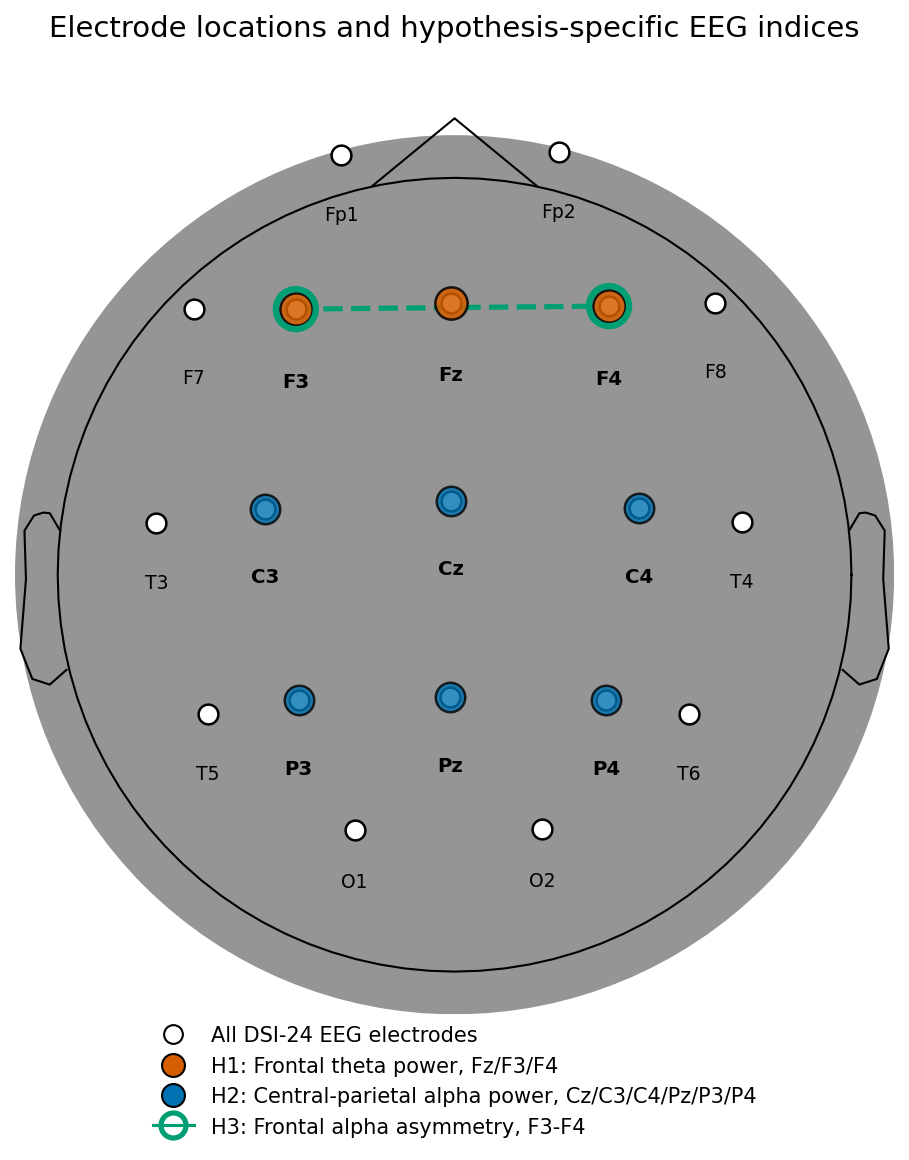

In [ ]:
# ============================================================
# Electrode-location figure for DSI-24 / 10-20 layout
# Highlighting electrodes used for H1, H2, and H3
#
# H1: Frontal theta power
#     Fz, F3, F4
#
# H2: Central-parietal alpha power
#     Cz, C3, C4, Pz, P3, P4
#     Note: This is alpha power, not alpha suppression,
#     because no clean pre-conversation baseline is available.
#
# H3: Frontal alpha asymmetry
#     F3, F4
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import mne
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Define electrodes used in your study
# ------------------------------------------------------------

dsi_channels = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "C3", "Cz", "C4",
    "T3", "T4", "T5", "T6",
    "P3", "Pz", "P4",
    "O1", "O2"
]

h1_theta_channels = ["Fz", "F3", "F4"]

# Revised to match manuscript:
# Central-parietal alpha power = Cz, C3, C4, Pz, P3, P4
h2_alpha_channels = ["Cz", "C3", "C4", "Pz", "P3", "P4"]

h3_faa_channels = ["F3", "F4"]

# ------------------------------------------------------------
# 2. Convert older 10-20 names to MNE-compatible names
# ------------------------------------------------------------

alias_to_mne = {
    "T3": "T7",
    "T4": "T8",
    "T5": "P7",
    "T6": "P8"
}

mne_to_display = {
    "T7": "T3",
    "T8": "T4",
    "P7": "T5",
    "P8": "T6"
}

def to_mne_name(ch):
    return alias_to_mne.get(ch, ch)

def to_display_name(ch):
    return mne_to_display.get(ch, ch)

dsi_channels_mne = [to_mne_name(ch) for ch in dsi_channels]
h1_mne = [to_mne_name(ch) for ch in h1_theta_channels]
h2_mne = [to_mne_name(ch) for ch in h2_alpha_channels]
h3_mne = [to_mne_name(ch) for ch in h3_faa_channels]

highlighted = sorted(set(h1_mne + h2_mne + h3_mne))

# ------------------------------------------------------------
# 3. Create MNE Info object with standard 10-20 coordinates
# ------------------------------------------------------------

montage = mne.channels.make_standard_montage("standard_1020")

info = mne.create_info(
    ch_names=dsi_channels_mne,
    sfreq=300,
    ch_types="eeg"
)

info.set_montage(montage, on_missing="ignore")

# ------------------------------------------------------------
# 4. Extract 2D topomap coordinates
# ------------------------------------------------------------

coords = mne.channels.layout._find_topomap_coords(
    info,
    picks=np.arange(len(dsi_channels_mne))
)

coord_df = {
    ch: coords[i]
    for i, ch in enumerate(dsi_channels_mne)
}

# ------------------------------------------------------------
# 5. Helper function for close electrode labels
# ------------------------------------------------------------

def add_close_label(
    ax,
    x,
    y,
    label,
    fontsize=9,
    fontweight="normal",
    zorder=10,
    dx=0.0,
    dy=None
):
    """
    Add a label close to the electrode marker.

    By default, labels are placed just below the marker.
    The offset is intentionally small so labels remain visually tied
    to their electrode location.
    """

    if dy is None:
        dy = -0.014

    ax.text(
        x + dx,
        y + dy,
        label,
        ha="center",
        va="top",
        fontsize=fontsize,
        fontweight=fontweight,
        color="black",
        zorder=zorder
    )

# ------------------------------------------------------------
# 6. Figure settings
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.8, 7.8))

mne.viz.plot_topomap(
    data=np.zeros(len(dsi_channels_mne)),
    pos=coords,
    axes=ax,
    show=False,
    contours=0,
    sensors=False,
    cmap="Greys",
    vlim=(-1, 1)
)

# ------------------------------------------------------------
# 7. Base electrodes and labels
#    Highlighted channels are labeled later, only once.
# ------------------------------------------------------------

for ch in dsi_channels_mne:
    x, y = coord_df[ch]

    ax.scatter(
        x,
        y,
        s=90,
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        zorder=3
    )

    # Skip highlighted labels here to avoid duplication
    if ch in highlighted:
        continue

    dx = 0.0
    dy = -0.014

    # Small manual refinements for outer electrodes
    if ch in ["Fp1", "Fp2"]:
        dy = -0.012

    if ch in ["O1", "O2"]:
        dy = -0.010

    if ch in ["P7", "P8"]:  # displayed as T5/T6
        dy = -0.012

    if ch in ["T7", "T8"]:  # displayed as T3/T4
        dy = -0.012

    add_close_label(
        ax,
        x,
        y,
        to_display_name(ch),
        fontsize=9,
        fontweight="normal",
        dx=dx,
        dy=dy,
        zorder=4
    )

# ------------------------------------------------------------
# 8. Highlight H1, H2, and H3 electrodes
# ------------------------------------------------------------

# H1: frontal theta power
for ch in h1_mne:
    x, y = coord_df[ch]
    ax.scatter(
        x,
        y,
        s=240,
        facecolor="#D55E00",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.85,
        zorder=5
    )

# H2: central-parietal alpha power
for ch in h2_mne:
    x, y = coord_df[ch]
    ax.scatter(
        x,
        y,
        s=200,
        facecolor="#0072B2",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.80,
        zorder=6
    )

# H3: frontal alpha asymmetry
for ch in h3_mne:
    x, y = coord_df[ch]
    ax.scatter(
        x,
        y,
        s=370,
        facecolor="none",
        edgecolor="#009E73",
        linewidth=3.0,
        zorder=7
    )

# Dashed line between F3 and F4
x_f3, y_f3 = coord_df[to_mne_name("F3")]
x_f4, y_f4 = coord_df[to_mne_name("F4")]

ax.plot(
    [x_f3, x_f4],
    [y_f3, y_f4],
    color="#009E73",
    linewidth=2.5,
    linestyle="--",
    zorder=2
)

# ------------------------------------------------------------
# 9. Add bold labels for highlighted channels, close to nodes
# ------------------------------------------------------------

for ch in highlighted:
    x, y = coord_df[ch]

    dx = 0.0
    dy = -0.016

    # Slightly closer labels for frontal electrodes
    if ch in ["F3", "Fz", "F4"]:
        dy = -0.015

    # Slightly closer labels for central/parietal electrodes
    if ch in ["C3", "Cz", "C4", "Pz", "P3", "P4"]:
        dy = -0.014

    add_close_label(
        ax,
        x,
        y,
        to_display_name(ch),
        fontsize=9.5,
        fontweight="bold",
        dx=dx,
        dy=dy,
        zorder=10
    )

# ------------------------------------------------------------
# 10. Legend
# ------------------------------------------------------------

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="All DSI-24 EEG electrodes",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="H1: Frontal theta power, Fz/F3/F4",
        markerfacecolor="#D55E00",
        markeredgecolor="black",
        markersize=11
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="H2: Central-parietal alpha power, Cz/C3/C4/Pz/P3/P4",
        markerfacecolor="#0072B2",
        markeredgecolor="black",
        markersize=11
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="#009E73",
        label="H3: Frontal alpha asymmetry, F3-F4",
        markerfacecolor="none",
        markeredgewidth=2.5,
        markersize=12
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False,
    fontsize=10,
    ncol=1
)

# ------------------------------------------------------------
# 11. Title and save
# ------------------------------------------------------------

ax.set_title(
    "Electrode locations and hypothesis-specific EEG indices",
    fontsize=14,
    pad=18
)

plt.tight_layout()

plt.savefig(
    "figure_electrode_locations_H1_H2_H3.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "figure_electrode_locations_H1_H2_H3.pdf",
    bbox_inches="tight"
)

plt.show()

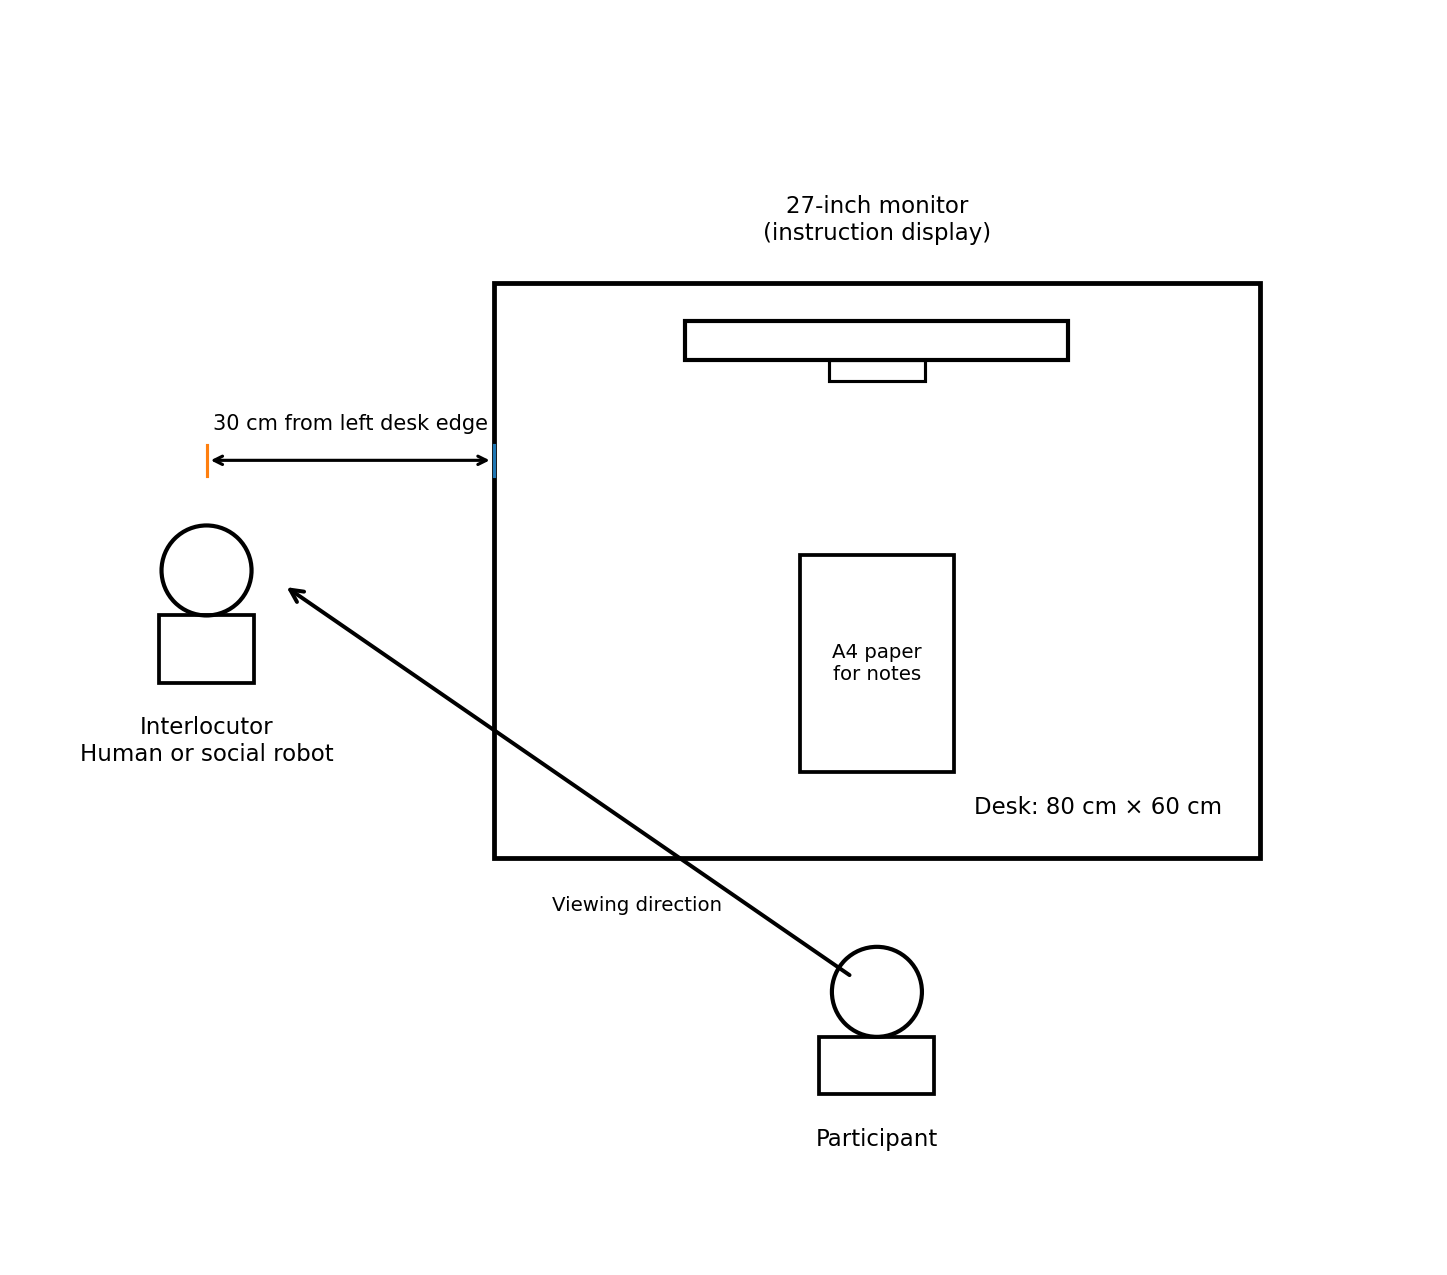

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import os

# ============================================================
# Experimental setup schematic for methods section
# Top-down view
# Main spatial layout uses cm-based coordinates
# ============================================================

fig, ax = plt.subplots(figsize=(11.8, 8.6))

# ------------------------------------------------------------
# 1. Desk: 80 cm width × 60 cm depth
# ------------------------------------------------------------

desk_x, desk_y = 0, 0
desk_w, desk_h = 80, 60

desk = Rectangle(
    (desk_x, desk_y),
    desk_w,
    desk_h,
    fill=False,
    linewidth=2.3
)
ax.add_patch(desk)

# Desk label placed in the lower-right area so it does not overlap with paper
ax.text(
    desk_x + desk_w - 4,
    desk_y + 4,
    "Desk: 80 cm × 60 cm",
    ha="right",
    va="bottom",
    fontsize=11
)

# ------------------------------------------------------------
# 2. Monitor
# ------------------------------------------------------------

monitor_w = 40
monitor_h = 4
monitor_x = desk_x + (desk_w - monitor_w) / 2
monitor_y = desk_y + desk_h - monitor_h - 4

monitor = Rectangle(
    (monitor_x, monitor_y),
    monitor_w,
    monitor_h,
    fill=False,
    linewidth=2
)
ax.add_patch(monitor)

# Monitor stand
stand_w = 10
stand_h = 2.2
stand_x = monitor_x + (monitor_w - stand_w) / 2
stand_y = monitor_y - stand_h

stand = Rectangle(
    (stand_x, stand_y),
    stand_w,
    stand_h,
    fill=False,
    linewidth=1.5
)
ax.add_patch(stand)

# Monitor label moved upward to avoid crowding the desk
ax.text(
    monitor_x + monitor_w / 2,
    monitor_y + monitor_h + 8.0,
    "27-inch monitor\n(instruction display)",
    ha="center",
    va="bottom",
    fontsize=11
)

# ------------------------------------------------------------
# 3. A4 paper, smaller schematic version
# Placed in front of participant and between participant and monitor
# ------------------------------------------------------------

# Smaller A4-proportional schematic, not actual full size
paper_w = 16
paper_h = 22.6
paper_x = desk_x + (desk_w - paper_w) / 2
paper_y = desk_y + 9

paper = Rectangle(
    (paper_x, paper_y),
    paper_w,
    paper_h,
    fill=False,
    linewidth=1.8
)
ax.add_patch(paper)

ax.text(
    paper_x + paper_w / 2,
    paper_y + paper_h / 2,
    "A4 paper\nfor notes",
    ha="center",
    va="center",
    fontsize=9.5
)

# ------------------------------------------------------------
# 4. Participant
# ------------------------------------------------------------

participant_x = desk_x + desk_w / 2
participant_y = desk_y - 14

participant_r = 4.7
participant_head = Circle(
    (participant_x, participant_y),
    radius=participant_r,
    fill=False,
    linewidth=2
)
ax.add_patch(participant_head)

# Body is placed below the head, just touching the circle
participant_body_w = 12
participant_body_h = 6
participant_body_top = participant_y - participant_r
participant_body_y = participant_body_top - participant_body_h

participant_body = Rectangle(
    (participant_x - participant_body_w / 2, participant_body_y),
    participant_body_w,
    participant_body_h,
    fill=False,
    linewidth=1.8
)
ax.add_patch(participant_body)

# Participant label below the participant
ax.text(
    participant_x,
    participant_body_y - 3.5,
    "Participant",
    ha="center",
    va="top",
    fontsize=11
)

# ------------------------------------------------------------
# 5. Interlocutor: Human or social robot
# Positioned 30 cm from the left edge of the desk
# ------------------------------------------------------------

interlocutor_x = desk_x - 30
interlocutor_y = desk_y + 30

interlocutor_r = 4.7
interlocutor_head = Circle(
    (interlocutor_x, interlocutor_y),
    radius=interlocutor_r,
    fill=False,
    linewidth=2
)
ax.add_patch(interlocutor_head)

# Body is placed below the circle, just touching the circle
inter_body_w = 10
inter_body_h = 7
inter_body_top = interlocutor_y - interlocutor_r
inter_body_y = inter_body_top - inter_body_h

interlocutor_body = Rectangle(
    (interlocutor_x - inter_body_w / 2, inter_body_y),
    inter_body_w,
    inter_body_h,
    fill=False,
    linewidth=1.8
)
ax.add_patch(interlocutor_body)

# Interlocutor label below icon, with clear wording
ax.text(
    interlocutor_x,
    inter_body_y - 3.5,
    "Interlocutor\nHuman or social robot",
    ha="center",
    va="top",
    fontsize=11
)

# ------------------------------------------------------------
# 6. Participant viewing direction
# Arrow points toward the interlocutor
# ------------------------------------------------------------

arrow_view = FancyArrowPatch(
    (participant_x - 2.5, participant_y + 1.5),
    (interlocutor_x + 8, interlocutor_y - 1.5),
    arrowstyle="->",
    mutation_scale=15,
    linewidth=1.9
)
ax.add_patch(arrow_view)

ax.text(
    participant_x - 25,
    participant_y + 9,
    "Viewing direction",
    ha="center",
    va="center",
    fontsize=9.5
)

# ------------------------------------------------------------
# 7. Distance annotation
# 30 cm from left desk edge
# ------------------------------------------------------------

dist_y = interlocutor_y + 11.5

ax.annotate(
    "",
    xy=(desk_x, dist_y),
    xytext=(interlocutor_x, dist_y),
    arrowprops=dict(arrowstyle="<->", linewidth=1.5)
)

# Guide ticks
ax.plot(
    [desk_x, desk_x],
    [dist_y - 1.6, dist_y + 1.6],
    linewidth=1.5
)

ax.plot(
    [interlocutor_x, interlocutor_x],
    [dist_y - 1.6, dist_y + 1.6],
    linewidth=1.5
)

ax.text(
    (desk_x + interlocutor_x) / 2,
    dist_y + 2.8,
    "30 cm from left desk edge",
    ha="center",
    va="bottom",
    fontsize=10
)


# ------------------------------------------------------------
# 9. Figure formatting
# ------------------------------------------------------------

ax.set_xlim(-50, 98)
ax.set_ylim(-42, 88)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

# ------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------

plt.savefig(
    "experimental_setup_schematic_revised.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "experimental_setup_schematic_revised.pdf",
    bbox_inches="tight"
)

plt.show()

Topomap sample: complete-pair H1-H3 sample
Subjects in topomap sample: 17
['25_06_25_1_1', '25_06_25_2_2', '25_07_01_2_2', '25_07_01_4_4', '25_07_01_6_6', '25_07_01_8_8', '25_07_02_3_3', '25_07_02_4_4', '25_07_02_5_5', '25_07_05_1_1', '25_07_05_4_4', '25_07_05_8_8', '25_07_11_1_1', '25_07_12_4_4', '25_07_12_5_5', '25_07_12_6_6', '25_07_12_8_8']
Topography dataframe rows: 680


,subjectID,condition,channel,channel_mne,theta_mean,alpha_mean,n_epochs
0,25_06_25_1_1,AI,Fp1,Fp1,-113.727497,-115.018790,250
1,25_06_25_1_1,AI,Fp2,Fp2,-113.967430,-115.012831,250
2,25_06_25_1_1,AI,Fz,Fz,-115.285361,-116.997796,250
3,25_06_25_1_1,AI,F3,F3,-117.527857,-118.107982,250
4,25_06_25_1_1,AI,F4,F4,-116.971072,-117.737999,250


Topomap complete channel-pair rows: 340
Topomap subjects after channel-pair filtering: 17
Channels used in topomap:
['A1', 'A2', 'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']
Shared color limits: 0.4269200679061494 1.4839714846356507
Colormap: YlOrRd


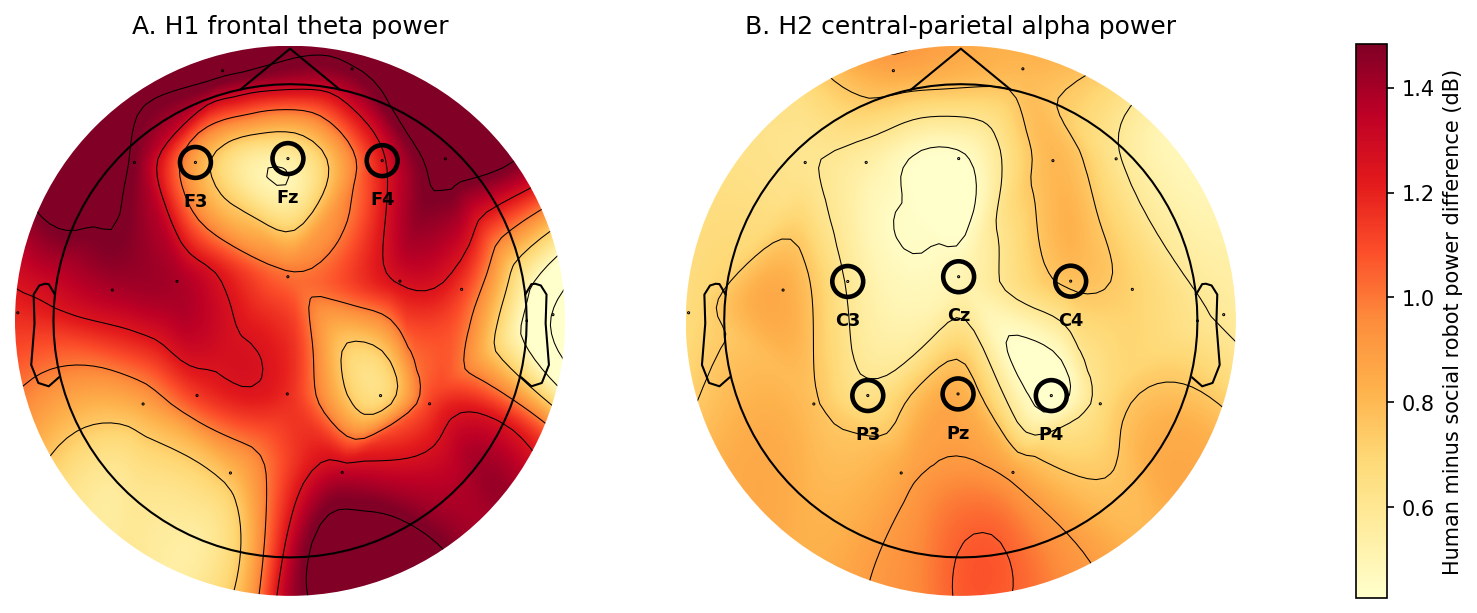

In [ ]:
# ============================================================
# FIGURE 4. Descriptive topographic maps for H1 and H2
#
# Purpose:
#   Visualize the descriptive scalp distribution of
#   Human minus social robot power differences for:
#     - H1: frontal theta power
#     - H2: central-parietal alpha power
#
# Notes:
#   - H3 is not mapped because frontal alpha asymmetry is a
#     left-right frontal contrast rather than a scalp field.
#   - Human minus social robot topomaps require both conditions.
#   - Therefore, this descriptive figure uses complete condition
#     pairs for each channel.
#
# Required objects from earlier blocks:
#   df_summary
#   df_wide or df_wide_complete
#   EPOCHS_DIR or epochs_dir
#   OUT_DIR or out_dir
#   THETA_BAND
#   ALPHA_BAND
#   REJECT_UV
#   MIN_EPOCHS_PER_COND
#   ROBOT_EVENT
#   HUMAN_EVENT
#   to_volts()
#   keep_by_ptp()
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import mne
from scipy.signal import welch

# ------------------------------------------------------------
# 0. Robust path and variable handling
# ------------------------------------------------------------

EPOCHS_PATH = globals().get("EPOCHS_DIR", globals().get("epochs_dir", None))
OUT_PATH = globals().get("OUT_DIR", globals().get("out_dir", None))

if EPOCHS_PATH is None:
    raise NameError("Neither EPOCHS_DIR nor epochs_dir is defined.")

if OUT_PATH is None:
    raise NameError("Neither OUT_DIR nor out_dir is defined.")

if "ROBOT_EVENT" not in globals():
    ROBOT_EVENT = "AI"

if "HUMAN_EVENT" not in globals():
    HUMAN_EVENT = "Human"

if "THETA_BAND" not in globals():
    THETA_BAND = (4, 8)

if "ALPHA_BAND" not in globals():
    ALPHA_BAND = (8, 12)

if "REJECT_UV" not in globals():
    REJECT_UV = 300

if "MIN_EPOCHS_PER_COND" not in globals():
    MIN_EPOCHS_PER_COND = 10

# ------------------------------------------------------------
# 1. Select subjects for the topomap
# ------------------------------------------------------------
# Use complete-pair subjects because Human minus social robot
# differences require both conditions.

if "df_wide_complete" in globals() and len(df_wide_complete) > 0:
    subject_ids_topo = set(df_wide_complete["subjectID"].astype(str))
    topo_sample_label = "complete-pair H1-H3 sample"
else:
    required_wide_cols = [
        f"theta_mean_{ROBOT_EVENT}", f"theta_mean_{HUMAN_EVENT}",
        f"alpha_mean_{ROBOT_EVENT}", f"alpha_mean_{HUMAN_EVENT}"
    ]

    if "df_wide" not in globals():
        raise NameError("df_wide is not defined. Run the participant-condition wide-format block first.")

    for col in required_wide_cols:
        if col not in df_wide.columns:
            df_wide[col] = np.nan

    df_wide_topo = df_wide.dropna(subset=required_wide_cols).copy()
    subject_ids_topo = set(df_wide_topo["subjectID"].astype(str))
    topo_sample_label = "complete-pair subjects identified from df_wide"

df_summary_topo = df_summary[
    df_summary["subjectID"].astype(str).isin(subject_ids_topo)
].copy()

print("Topomap sample:", topo_sample_label)
print("Subjects in topomap sample:", len(subject_ids_topo))
print(sorted(subject_ids_topo))

# Because your epoch files were saved as:
#     {row_index}_sliding-epo.fif
# preserve the row index from df_summary
topo_row_ids = df_summary_topo.index.tolist()

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def old_1020_to_mne(ch):
    mapping = {
        "T3": "T7",
        "T4": "T8",
        "T5": "P7",
        "T6": "P8",
        "Pz-0": "Pz"
    }
    return mapping.get(ch, ch)


def mne_to_old_1020(ch):
    mapping = {
        "T7": "T3",
        "T8": "T4",
        "P7": "T5",
        "P8": "T6"
    }
    return mapping.get(ch, ch)


def bandpower_db_epoch_channelwise(epochs, fmin, fmax):
    """
    Compute epoch × channel band power in dB using Welch.
    Returns array with shape: n_epochs × n_channels.
    """
    data = epochs.get_data()
    sfreq = epochs.info["sfreq"]

    n_epochs, n_channels, _ = data.shape
    out = np.full((n_epochs, n_channels), np.nan, dtype=float)

    nperseg = int(sfreq * 1.0)

    for i in range(n_epochs):
        for j in range(n_channels):
            f, p = welch(
                data[i, j, :],
                fs=sfreq,
                nperseg=nperseg,
                noverlap=nperseg // 2
            )

            mask = (f >= fmin) & (f <= fmax)

            if np.any(mask):
                p_db = 10 * np.log10(p + 1e-12)
                out[i, j] = np.nanmean(p_db[mask])

    return out


def find_epoch_file(row_index, subject_id):
    """
    First tries the row-index file name used by your pipeline.
    If not found, tries subjectID-based file name as a fallback.
    """
    f1 = os.path.join(EPOCHS_PATH, f"{row_index}_sliding-epo.fif")
    f2 = os.path.join(EPOCHS_PATH, f"{subject_id}_sliding-epo.fif")

    if os.path.exists(f1):
        return f1
    if os.path.exists(f2):
        return f2
    return None


def plot_topomap_compat(data, pos, ax, cmap, vmin, vmax, title):
    """
    Compatibility wrapper for different MNE versions.
    """
    try:
        im, _ = mne.viz.plot_topomap(
            data,
            pos,
            axes=ax,
            show=False,
            contours=6,
            cmap=cmap,
            vlim=(vmin, vmax),
            sensors=True
        )
    except TypeError:
        im, _ = mne.viz.plot_topomap(
            data,
            pos,
            axes=ax,
            show=False,
            contours=6,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            sensors=True
        )

    ax.set_title(title, fontsize=12)
    return im


def add_hypothesis_channels(ax, channel_to_xy, channels, label_offset=-0.012):
    """
    Circle and label hypothesis-relevant electrodes.
    """
    for ch in channels:
        if ch in channel_to_xy:
            x, y = channel_to_xy[ch]

            ax.scatter(
                x,
                y,
                s=220,
                facecolor="none",
                edgecolor="black",
                linewidth=2.2,
                zorder=10
            )

            ax.text(
                x,
                y + label_offset,
                mne_to_old_1020(ch),
                ha="center",
                va="top",
                fontsize=8.5,
                fontweight="bold",
                zorder=11
            )


def shared_robust_limits(theta_data, alpha_data, lower=5, upper=95):
    """
    Compute one shared robust color scale across theta and alpha maps.
    """
    combined = np.concatenate([
        np.asarray(theta_data, dtype=float),
        np.asarray(alpha_data, dtype=float)
    ])

    combined = combined[np.isfinite(combined)]

    vmin = np.percentile(combined, lower)
    vmax = np.percentile(combined, upper)

    if np.isclose(vmin, vmax):
        vmin = np.nanmin(combined)
        vmax = np.nanmax(combined)

    return vmin, vmax


def shared_signed_limits(theta_data, alpha_data, upper=95):
    """
    Compute one shared symmetric color scale centered at zero.
    """
    combined = np.concatenate([
        np.asarray(theta_data, dtype=float),
        np.asarray(alpha_data, dtype=float)
    ])

    combined = combined[np.isfinite(combined)]

    vmax = np.percentile(np.abs(combined), upper)

    if vmax == 0 or np.isnan(vmax):
        vmax = np.nanmax(np.abs(combined))

    return -vmax, vmax

# ------------------------------------------------------------
# 3. Compute participant × condition × channel means
# ------------------------------------------------------------

topo_rows = []

for row_idx in topo_row_ids:
    subject_id = str(df_summary.loc[row_idx, "subjectID"])
    fpath = find_epoch_file(row_idx, subject_id)

    if fpath is None:
        print(f"Missing epoch file for {subject_id}")
        continue

    try:
        eps = mne.read_epochs(fpath, preload=True, verbose=False)
        eps = to_volts(eps)
    except Exception as e:
        print(f"Could not read epochs for {subject_id}: {e}")
        continue

    if (ROBOT_EVENT not in eps.event_id) or (HUMAN_EVENT not in eps.event_id):
        print(f"Missing condition event for {subject_id}")
        continue

    eeg_picks = mne.pick_types(
        eps.info,
        eeg=True,
        eog=False,
        stim=False,
        exclude=[]
    )

    if len(eeg_picks) == 0:
        print(f"No EEG channels found for {subject_id}")
        continue

    eps = eps.copy().pick(eeg_picks)

    for cond in [ROBOT_EVENT, HUMAN_EVENT]:
        e = eps[cond].copy().load_data()

        keep = keep_by_ptp(e, uv=REJECT_UV)
        e = e[keep]

        if len(e) < MIN_EPOCHS_PER_COND:
            continue

        theta_arr = bandpower_db_epoch_channelwise(
            e,
            THETA_BAND[0],
            THETA_BAND[1]
        )

        alpha_arr = bandpower_db_epoch_channelwise(
            e,
            ALPHA_BAND[0],
            ALPHA_BAND[1]
        )

        theta_mean_ch = np.nanmean(theta_arr, axis=0)
        alpha_mean_ch = np.nanmean(alpha_arr, axis=0)

        for ch_i, ch in enumerate(e.ch_names):
            topo_rows.append({
                "subjectID": subject_id,
                "condition": cond,
                "channel": ch,
                "channel_mne": old_1020_to_mne(ch),
                "theta_mean": theta_mean_ch[ch_i],
                "alpha_mean": alpha_mean_ch[ch_i],
                "n_epochs": len(e)
            })

df_topo = pd.DataFrame(topo_rows)

print("Topography dataframe rows:", len(df_topo))

if len(df_topo) == 0:
    raise ValueError("df_topo is empty. Check epoch paths, event labels, and minimum epoch criteria.")

display(df_topo.head())

df_topo.to_csv(
    os.path.join(OUT_PATH, "topomap_participant_condition_channel_means.csv"),
    index=False
)

# ------------------------------------------------------------
# 4. Convert to Human minus social robot channel differences
# ------------------------------------------------------------

df_topo_wide = df_topo.pivot_table(
    index=["subjectID", "channel_mne"],
    columns="condition",
    values=["theta_mean", "alpha_mean"],
    aggfunc="mean",
    observed=True
)

df_topo_wide.columns = [
    f"{metric}_{condition}"
    for metric, condition in df_topo_wide.columns
]

df_topo_wide = df_topo_wide.reset_index()

needed_topo_cols = [
    f"theta_mean_{ROBOT_EVENT}",
    f"theta_mean_{HUMAN_EVENT}",
    f"alpha_mean_{ROBOT_EVENT}",
    f"alpha_mean_{HUMAN_EVENT}"
]

for col in needed_topo_cols:
    if col not in df_topo_wide.columns:
        df_topo_wide[col] = np.nan

df_topo_wide = df_topo_wide.dropna(subset=needed_topo_cols).copy()

df_topo_wide["theta_diff"] = (
    df_topo_wide[f"theta_mean_{HUMAN_EVENT}"]
    - df_topo_wide[f"theta_mean_{ROBOT_EVENT}"]
)

df_topo_wide["alpha_diff"] = (
    df_topo_wide[f"alpha_mean_{HUMAN_EVENT}"]
    - df_topo_wide[f"alpha_mean_{ROBOT_EVENT}"]
)

df_topo_wide.to_csv(
    os.path.join(OUT_PATH, "topomap_human_minus_social_robot_channel_differences.csv"),
    index=False
)

print("Topomap complete channel-pair rows:", len(df_topo_wide))
print("Topomap subjects after channel-pair filtering:", df_topo_wide["subjectID"].nunique())

# Average Human minus social robot difference at each channel
theta_topo = (
    df_topo_wide
    .groupby("channel_mne", as_index=False, observed=True)["theta_diff"]
    .mean()
)

alpha_topo = (
    df_topo_wide
    .groupby("channel_mne", as_index=False, observed=True)["alpha_diff"]
    .mean()
)

common_channels = sorted(
    set(theta_topo["channel_mne"]).intersection(set(alpha_topo["channel_mne"]))
)

if len(common_channels) == 0:
    raise ValueError("No common channels found for theta and alpha topomaps.")

theta_topo = (
    theta_topo
    .set_index("channel_mne")
    .loc[common_channels]
    .reset_index()
)

alpha_topo = (
    alpha_topo
    .set_index("channel_mne")
    .loc[common_channels]
    .reset_index()
)

theta_data = theta_topo["theta_diff"].values
alpha_data = alpha_topo["alpha_diff"].values

print("Channels used in topomap:")
print(common_channels)

# ------------------------------------------------------------
# 5. Build MNE topomap coordinates
# ------------------------------------------------------------

montage = mne.channels.make_standard_montage("standard_1020")

info_topo = mne.create_info(
    ch_names=common_channels,
    sfreq=300,
    ch_types="eeg"
)

info_topo.set_montage(montage, on_missing="ignore")

pos = mne.channels.layout._find_topomap_coords(
    info_topo,
    picks=np.arange(len(common_channels))
)

channel_to_xy = {
    ch: pos[i]
    for i, ch in enumerate(common_channels)
}

# H1 channels
h1_mne = [old_1020_to_mne(ch) for ch in ["Fz", "F3", "F4"]]

# H2 channels revised to match manuscript
h2_mne = [old_1020_to_mne(ch) for ch in ["Cz", "C3", "C4", "Pz", "P3", "P4"]]

# ------------------------------------------------------------
# 6. Shared color scale selection
# ------------------------------------------------------------

CENTER_ZERO = False

if CENTER_ZERO:
    shared_vmin, shared_vmax = shared_signed_limits(
        theta_data,
        alpha_data,
        upper=95
    )
    CMAP = "RdBu_r"
else:
    shared_vmin, shared_vmax = shared_robust_limits(
        theta_data,
        alpha_data,
        lower=5,
        upper=95
    )

    if shared_vmin >= 0:
        CMAP = "YlOrRd"
    elif shared_vmax <= 0:
        CMAP = "Blues_r"
    else:
        CMAP = "RdBu_r"

print("Shared color limits:", shared_vmin, shared_vmax)
print("Colormap:", CMAP)

# ------------------------------------------------------------
# 7. Plot figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(11.8, 4.8))

gs = GridSpec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.055],
    wspace=0.32
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Panel A: H1 frontal theta power
im1 = plot_topomap_compat(
    theta_data,
    pos,
    ax=ax1,
    cmap=CMAP,
    vmin=shared_vmin,
    vmax=shared_vmax,
    title="A. H1 frontal theta power"
)

add_hypothesis_channels(
    ax1,
    channel_to_xy,
    h1_mne,
    label_offset=-0.012
)

# Panel B: H2 central-parietal alpha power
im2 = plot_topomap_compat(
    alpha_data,
    pos,
    ax=ax2,
    cmap=CMAP,
    vmin=shared_vmin,
    vmax=shared_vmax,
    title="B. H2 central-parietal alpha power"
)

add_hypothesis_channels(
    ax2,
    channel_to_xy,
    h2_mne,
    label_offset=-0.012
)

cb = plt.colorbar(im2, cax=cax)
cb.set_label("Human minus social robot power difference (dB)")

plt.savefig(
    os.path.join(OUT_PATH, "figure4_topomap_h1_h2_shared_scale.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_PATH, "figure4_topomap_h1_h2_shared_scale.pdf"),
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
import mne

# Check several saved epoch files
for f in sorted(os.listdir(EPOCHS_DIR))[:5]:
    if f.endswith("-epo.fif"):
        path = os.path.join(EPOCHS_DIR, f)
        eps = mne.read_epochs(path, preload=False, verbose=False)

        print("\nFile:", f)
        print("Sampling rate:", eps.info["sfreq"])
        print("High-pass:", eps.info["highpass"])
        print("Low-pass:", eps.info["lowpass"])
        print("Channels:", eps.ch_names)
        print("Custom reference applied:", eps.info.get("custom_ref_applied"))


File: 0_sliding-epo.fif
Sampling rate: 300.0
High-pass: 0.10000000149011612
Low-pass: 30.0
Channels: ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz-0', 'P3', 'P4', 'O1', 'O2', 'A1']
Custom reference applied: 1

File: 10_sliding-epo.fif
Sampling rate: 300.0
High-pass: 0.10000000149011612
Low-pass: 30.0
Channels: ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz-0', 'P3', 'P4', 'O1', 'O2', 'A1']
Custom reference applied: 1

File: 11_sliding-epo.fif
Sampling rate: 300.0
High-pass: 0.10000000149011612
Low-pass: 30.0
Channels: ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz-0', 'P3', 'P4', 'O1', 'O2', 'A1']
Custom reference applied: 1

File: 12_sliding-epo.fif
Sampling rate: 300.0
High-pass: 0.10000000149011612
Low-pass: 30.0
Channels: ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz-0', 'P3', 'P4', 'O1', 'O2', 'A1']
Custo